<a href="https://colab.research.google.com/github/hozaifbinFarid/rpmt-missingness-transport/blob/main/RPMT_Complete_Research_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# RPMT research notebook
## Rate Preserving Missingness Transport for multisensor fusion

This self-contained notebook implements the experiment in **RPMT_Research_Discovery_and_Proposal.docx**: data preparation, the transport adversary, fusion models, ten comparison methods, four ablations, resumable checkpoints, evaluation, figures, and exports.

**Validation supplied with this file:** every code cell has been executed sequentially in a fresh Python process with the NumPy CPU backend. Saved outputs are synthetic smoke results. PyTorch/CUDA execution, live UCI downloads, and the 293-fit real-data study have not been run here. Format-matched fixtures exercise all three real-data parsers. No empirical research gain or measured Colab runtime is claimed.

### Quick start

1. Open in Jupyter or Colab and choose **Run all**. The default `MODE = "smoke"` performs 29 short synthetic fits without downloading datasets.
2. For Colab experiments, select a GPU runtime and set `MOUNT_GOOGLE_DRIVE = True` to keep checkpoints across runtime replacement. Choose a persistent `DEFAULT_ROOT` folder. Keep Colab's installed CUDA-compatible PyTorch. `INSTALL_MISSING = True` installs only missing general dependencies; restart after installing.
3. Set `MODE = "pilot"` to download the official datasets and time complete training passes, inner solves, validation, and checkpoint writes. Allow at least 8 GiB free disk. Inspect timing and convergence before committing to the step budget.
4. Set `MODE = "study"` to execute the frozen plan. A measured estimate over `max_study_hours` blocks the study. Reduce width/steps consistently, use a new output folder, and repeat the pilot before test inspection.
5. After an interruption, retain the same folder and configuration and choose **Run all**. Completed fits are verified and skipped; partial fits resume from the last saved outer step.

`RPMT_MODE`, `RPMT_BACKEND`, and `RPMT_ROOT` environment variables override the editable defaults. Use a fresh output folder for a changed, already evaluated protocol. Run one notebook writer per experiment folder.

| Component | Included |
|---|---|
| RPMT | Full empirical loss matrix; fixed example/full-mask marginals; KL budget; dual diagnostics |
| Data | MHEALTH, PAMAP2 Protocol, Multiple Features; subject splits, gap handling, feature caches and hashes |
| Comparisons | Ten methods, four constraint ablations, CE controls, lambda/rho sensitivity, raw and six-view paths |
| Recovery | Atomic container, previous checkpoint, integrity hashes, optimizer/RNG/method state, completion registry |
| Evaluation | Model-specific adversaries, shared exact-count mechanisms, calibration, subject summaries and paired bootstrap |
| Exports | CSV/JSON, figures, manifests, inference artifact, result ZIP, complete training checkpoints |

Compact literature baselines are adaptations, not reproductions of the authors' complete systems. Their exact definitions and limitations appear below.


## 1 Configuration and environment

Edit `MODE`, `BACKEND_REQUEST`, and the output folder here. The NumPy backend contains a small reverse-mode differentiation engine. The same model graph uses PyTorch autograd and CUDA when available. The transport solver stays in SciPy float64; the network uses float32. Actual resolved versions are recorded.

The default 30 outer steps are a starting real-study budget. Each outer step covers the entire training set twice. Inspect real-data learning curves before fixing the budget; a short smoke test does not establish convergence.


In [ ]:
import os, sys, json, math, time, hashlib, platform, random, copy, io, zipfile
import re, shutil, tempfile, warnings, importlib, importlib.metadata, urllib.request
from pathlib import Path
from dataclasses import dataclass, asdict, replace
from datetime import datetime, timezone
from itertools import combinations

# On Colab, set this True before Run all to survive a runtime replacement.
MODE = "study"                 # change to "pilot", then "study" after inspecting the pilot
BACKEND_REQUEST = "auto"        # prefers PyTorch when installed
MOUNT_GOOGLE_DRIVE = True
DEFAULT_ROOT = "./rpmt_runs"
if MOUNT_GOOGLE_DRIVE:
    try:
        from google.colab import drive
    except ImportError as error:
        raise RuntimeError("Drive mounting is available only inside Colab.") from error
    drive.mount("/content/drive")
    DEFAULT_ROOT = "/content/drive/MyDrive/RPMT"

# Keep Colab's installed CUDA stack. Installation is explicit and only fills gaps.
INSTALL_MISSING = False
requirements = {"numpy": "numpy>=1.26", "scipy": "scipy>=1.11",
                "pandas": "pandas>=2", "matplotlib": "matplotlib>=3.7"}
missing = [spec for module, spec in requirements.items()
           if importlib.util.find_spec(module) is None]
if missing and INSTALL_MISSING:
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])
elif missing:
    raise RuntimeError(f"Install {missing} or set INSTALL_MISSING=True, then restart.")

import numpy as np
import scipy
from scipy.special import logsumexp, xlogy
from scipy.optimize import minimize, linprog, least_squares, brentq
from scipy import sparse, signal
from scipy.integrate import trapezoid
import pandas as pd
import matplotlib.pyplot as plt

TORCH_AVAILABLE = importlib.util.find_spec("torch") is not None
if TORCH_AVAILABLE:
    import torch

@dataclass(frozen=True)
class Config:
    mode: str = "smoke"                 # smoke | pilot | study
    backend: str = "auto"               # auto | numpy | torch
    root: str = "./rpmt_runs"           # use mounted Drive for persistent Colab checkpoints
    seed: int = 2026
    seeds: tuple = (11, 29, 47)
    width: int = 64
    chunk: int = 128
    outer_steps: int = 30
    smoke_steps: int = 3
    learning_rate: float = 0.003
    beta: float = 1e-5
    rho_fraction: float = 0.15
    robust_weight: float = 0.5
    eval_fractions: tuple = (0., 0.05, 0.15, 0.30)
    checkpoint_every: int = 1
    validate_every: int = 5
    solver_tol: float = 2e-6
    max_study_hours: float = 15.0
    max_session_hours: float = 3.0
    bootstrap_repeats: int = 2000
    allow_downloads: bool = True
    window: int = 128
    stride: int = 64
    native_gap_seconds: float = 0.5

CFG = Config(root=os.environ.get("RPMT_ROOT", DEFAULT_ROOT),
             mode=os.environ.get("RPMT_MODE", MODE),
             backend=os.environ.get("RPMT_BACKEND", BACKEND_REQUEST))
assert CFG.mode in {"smoke", "pilot", "study"}
assert CFG.backend in {"auto", "numpy", "torch"}
assert CFG.chunk > 0 and CFG.outer_steps > 0 and CFG.checkpoint_every > 0
assert len(CFG.seeds)==3 and len(set(CFG.seeds))==3, "The prespecified study uses three distinct seeds."
assert sys.version_info >= (3,10), "Use Python 3.10 or newer."
assert 0 <= CFG.robust_weight <= 1 and CFG.rho_fraction >= 0
assert tuple(sorted(set(CFG.eval_fractions))) == CFG.eval_fractions
BACKEND = ("torch" if TORCH_AVAILABLE else "numpy") if CFG.backend == "auto" else CFG.backend
if BACKEND == "torch" and not TORCH_AVAILABLE:
    raise RuntimeError("PyTorch is unavailable. Use backend='numpy' for the reference smoke test.")
DEVICE = "cuda" if BACKEND == "torch" and torch.cuda.is_available() else "cpu"
if BACKEND == "torch":
    torch.set_num_threads(min(4, os.cpu_count() or 1))
    torch.use_deterministic_algorithms(True)
    torch.backends.cudnn.benchmark = False
    os.environ.setdefault("CUBLAS_WORKSPACE_CONFIG", ":4096:8")
ROOT = Path(CFG.root).expanduser().resolve()
ROOT.mkdir(parents=True, exist_ok=True)
for directory in ("downloads", "cache", "runs", "exports", "tests"):
    (ROOT / directory).mkdir(exist_ok=True)
PIPELINE_VERSION = "rpmt-notebook-1.0.0"
ENV = {"python": platform.python_version(), "numpy": np.__version__,
       "scipy": scipy.__version__, "pandas": pd.__version__,
       "matplotlib": importlib.metadata.version("matplotlib"),
       "backend": BACKEND, "device": DEVICE,
       "torch": str(torch.__version__) if TORCH_AVAILABLE else None}

def seed_all(seed):
    random.seed(seed); np.random.seed(seed)
    if TORCH_AVAILABLE:
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)

def canonical(value):
    return json.dumps(value, sort_keys=True, separators=(",", ":"), allow_nan=False)

def digest_json(value):
    return hashlib.sha256(canonical(value).encode()).hexdigest()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:

def digest_file(path):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for b in iter(lambda: f.read(1024 * 1024), b""):
            h.update(b)
    return h.hexdigest()

def atomic_bytes(path, payload):
    path = Path(path); path.parent.mkdir(parents=True, exist_ok=True)
    fd, tmp = tempfile.mkstemp(prefix=path.name + ".", suffix=".tmp", dir=path.parent)
    try:
        with os.fdopen(fd, "wb") as f:
            f.write(payload); f.flush(); os.fsync(f.fileno())
        os.replace(tmp, path)
    finally:
        if os.path.exists(tmp): os.unlink(tmp)

def atomic_json(path, value):
    atomic_bytes(path, (json.dumps(value, indent=2, sort_keys=True, allow_nan=False) + "\n").encode())

def save_bundle(path, metadata, arrays):
    # One atomic container; no pickle, executable objects, or mismatched sidecars.
    payload = io.BytesIO()
    np.savez_compressed(payload, **{k: np.asarray(v) for k, v in arrays.items()})
    data = payload.getvalue(); meta = canonical(metadata).encode()
    manifest = {"schema": 1, "arrays_sha256": hashlib.sha256(data).hexdigest(),
                "metadata_sha256": hashlib.sha256(meta).hexdigest()}
    out = io.BytesIO()
    with zipfile.ZipFile(out, "w", zipfile.ZIP_STORED) as z:
        z.writestr("arrays.npz", data); z.writestr("metadata.json", meta)
        z.writestr("manifest.json", canonical(manifest))
    atomic_bytes(path, out.getvalue())

def load_bundle(path):
    with zipfile.ZipFile(path) as z:
        meta = z.read("metadata.json"); data = z.read("arrays.npz")
        manifest = json.loads(z.read("manifest.json"))
    if manifest.get("schema") != 1 or hashlib.sha256(data).hexdigest() != manifest["arrays_sha256"] \
            or hashlib.sha256(meta).hexdigest() != manifest["metadata_sha256"]:
        raise ValueError(f"Corrupt or unsupported bundle: {path}")
    with np.load(io.BytesIO(data), allow_pickle=False) as a:
        arrays = {k: a[k].copy() for k in a.files}
    return json.loads(meta), arrays

seed_all(CFG.seed)
atomic_json(ROOT / "environment.json", ENV)
print(json.dumps({"mode": CFG.mode, **ENV, "free_disk_GB": round(shutil.disk_usage(ROOT).free / 1e9, 2)}, indent=2))
print("SMOKE OUTPUTS ARE SYNTHETIC ENGINEERING CHECKS." if CFG.mode == "smoke" else "Real-data mode selected.")


{
  "mode": "study",
  "python": "3.13.15",
  "numpy": "2.1.3",
  "scipy": "1.16.3",
  "pandas": "2.2.3",
  "matplotlib": "3.10.0",
  "backend": "torch",
  "device": "cuda",
  "torch": "2.11.0+cu128",
  "free_disk_GB": 63.11
}
Real-data mode selected.


## 2 Data acquisition and preprocessing

MHEALTH has three groups: chest acceleration **plus ECG**, ankle, and arm. PAMAP2 uses the ±16g acceleration, gyroscope, and magnetometer fields of each IMU; shared heart rate, temperature, the second acceleration range, and invalid orientations are excluded. Channel choices follow the [MHEALTH](https://archive.ics.uci.edu/dataset/319/mhealth+dataset) and [PAMAP2](https://archive.ics.uci.edu/dataset/231/pamap2+physical+activity+monitoring) documentation.

Select subjects before interpolation and windowing. Split recordings at activity changes, timestamp reversals/jumps, and file boundaries. Fill only bounded native gaps no longer than 0.5 seconds. PAMAP2 is resampled from 100 to 50 Hz using a segment-local 41-tap polyphase FIR filter; its support around remaining gaps is excluded. Never interpolate across an activity boundary. Use 128-sample windows with stride 64. Exclusion counts are retained; selecting complete windows limits external validity.

Eight per-channel statistics are mean, standard deviation, minimum, maximum, RMS, interquartile range, mean absolute successive difference, and slope per second. Fit standardization on training features only. The raw-window confirmation standardizes channels from training windows and uses a flattened-window MLP encoder.

| Dataset | Partition | Train subjects | Validation subjects | Test subjects |
|---|---:|---|---|---|
| MHEALTH | 0 | 1, 2, 3, 4, 5, 6 | 7, 8 | 9, 10 |
| MHEALTH | 1 | 3, 4, 5, 6, 7, 8 | 9, 10 | 1, 2 |
| MHEALTH | 2 | 1, 2, 5, 6, 9, 10 | 3, 4 | 7, 8 |
| PAMAP2 | 0 | 3, 4, 5, 6, 9 | 7, 8 | 1, 2 |
| PAMAP2 | 1 | 1, 2, 5, 6, 9 | 3, 4 | 7, 8 |
| PAMAP2 | 2 | 1, 2, 7, 8, 9 | 5, 6 | 3, 4 |

PAMAP2's sparse subject 9 remains in training. These partitions evaluate six distinct held-out people per sensor dataset, not every subject. Seeds are repeated fits, not new subjects. Multiple Features uses 120/40/40 examples per digit in one fixed stratified split. Primary feature-view widths are 76, 216, and 64; the six-view diagnostic adds the other three views. These are feature representations, not physical sensors.

Archives are hashed; retries are bounded; extraction rejects unsafe paths; numeric caches use `allow_pickle=False`. For offline use, place the official ZIPs at `ROOT/downloads/mhealth.zip`, `pamap2.zip`, and `mfeat.zip`. Leave `allow_downloads=True` for initial hash registration; existing archives are not downloaded again.


In [ ]:
SOURCES = {
    "mhealth": {"url": "https://archive.ics.uci.edu/static/public/319/mhealth+dataset.zip", "max_bytes": 120_000_000},
    "pamap2": {"url": "https://archive.ics.uci.edu/static/public/231/pamap2+physical+activity+monitoring.zip", "max_bytes": 800_000_000},
    "mfeat": {"url": "https://archive.ics.uci.edu/static/public/72/multiple+features.zip", "max_bytes": 20_000_000},
}
SUBJECT_SPLITS = {
    "mhealth": [([1,2,3,4,5,6], [7,8], [9,10]),
                ([3,4,5,6,7,8], [9,10], [1,2]),
                ([1,2,5,6,9,10], [3,4], [7,8])],
    "pamap2": [([3,4,5,6,9], [7,8], [1,2]),
               ([1,2,5,6,9], [3,4], [7,8]),
               ([1,2,7,8,9], [5,6], [3,4])],
}
PAMAP_CLASSES = (1,2,3,4,5,6,7,12,13,16,17,24)

def download_dataset(name):
    source = SOURCES[name]; path = ROOT / "downloads" / f"{name}.zip"
    manifest_path = path.with_suffix(".json")
    if path.exists() and manifest_path.exists():
        manifest = json.loads(manifest_path.read_text())
        if digest_file(path) != manifest["sha256"]:
            raise ValueError(f"Checksum mismatch in {path}; inspect/remove that cache before retrying.")
        return path, manifest
    if not CFG.allow_downloads:
        raise FileNotFoundError(f"Place the official archive at {path} and enable downloads once to record its hash.")
    # A locally placed official archive is accepted and hashed, without downloading again.
    if not path.exists():
        if shutil.disk_usage(ROOT).free < 8 * 1024**3:
            raise OSError("At least 8 GiB free disk is required before downloading real datasets.")
        partial = path.with_suffix(".partial")
        last_error = None
        for attempt in range(3):
            try:
                request = urllib.request.Request(source["url"], headers={"User-Agent": "RPMT-research-notebook/1.0"})
                with urllib.request.urlopen(request, timeout=90) as response, open(partial, "wb") as out:
                    size = 0
                    while True:
                        block = response.read(1024 * 1024)
                        if not block: break
                        size += len(block)
                        if size > source["max_bytes"]: raise ValueError("Archive exceeds the expected safety limit.")
                        out.write(block)
                    out.flush(); os.fsync(out.fileno())
                if not zipfile.is_zipfile(partial): raise ValueError("Response is not a ZIP archive.")
                os.replace(partial, path); break
            except (OSError, ValueError) as error:
                last_error = error
                if partial.exists(): partial.unlink()
                if attempt == 2: raise RuntimeError(f"Could not download {name}: {error}. Upload its official ZIP to {path}.") from error
                time.sleep(2 ** attempt)
    if not zipfile.is_zipfile(path): raise ValueError(f"Not a ZIP: {path}")
    manifest = {"source": source["url"], "sha256": digest_file(path), "bytes": path.stat().st_size,
                "recorded_utc": datetime.now(timezone.utc).isoformat(), "license": "CC BY 4.0 (UCI)"}
    atomic_json(manifest_path, manifest)
    return path, manifest

def unpack_official(path, name):
    destination = ROOT / "downloads" / name
    marker = destination / "extraction.json"
    archive_hash = digest_file(path)
    if marker.exists() and json.loads(marker.read_text()).get("sha256") == archive_hash:
        return destination
    destination.mkdir(exist_ok=True)
    def extract_one(archive):
        with zipfile.ZipFile(archive) as z:
            for member in z.infolist():
                target = (destination / member.filename).resolve()
                if not target.is_relative_to(destination.resolve()): raise ValueError("Unsafe ZIP path.")
                if (member.external_attr >> 16) & 0o170000 == 0o120000: raise ValueError("ZIP symlink rejected.")
            if sum(x.file_size for x in z.infolist()) > 5 * 1024**3: raise ValueError("Expanded archive exceeds 5 GiB.")
            z.extractall(destination)
    extract_one(path)
    # UCI packages may wrap the original dataset ZIP once.
    for nested in sorted(destination.rglob("*.zip")):
        extract_one(nested)
    atomic_json(marker, {"sha256": archive_hash})
    return destination

@dataclass
class Data:
    x: list
    y: np.ndarray
    subject: np.ndarray
    ids: np.ndarray
    quality: np.ndarray
    meta: dict
    def __len__(self): return len(self.y)
    def subset(self, indices):
        return Data([v[indices] for v in self.x], self.y[indices], self.subject[indices],
                    self.ids[indices], self.quality[indices], copy.deepcopy(self.meta))
    def check(self):
        n = len(self)
        assert n > 0 and len(self.x) >= 2 and self.y.dtype.kind in "iu"
        assert self.y.ndim == 1 and np.min(self.y) >= 0
        assert len(set(self.ids.tolist())) == n, "Duplicate example identifiers"
        assert all(len(v) == n and np.isfinite(v).all() for v in self.x)
        assert self.quality.shape == (n,) and np.isfinite(self.quality).all()
        return self

def data_hash(data):
    h = hashlib.sha256(canonical(data.meta).encode())
    for a in [*data.x, data.y, data.subject, data.ids, data.quality]:
        a = np.ascontiguousarray(a)
        h.update(str(a.dtype).encode()); h.update(str(a.shape).encode()); h.update(a.tobytes())
    return h.hexdigest()

def cache_data(path, data):
    arrays = {f"x{j}": a for j, a in enumerate(data.x)}
    arrays.update(y=data.y, subject=data.subject, ids=data.ids, quality=data.quality)
    save_bundle(path, {"meta": data.meta, "n_views": len(data.x), "data_hash": data_hash(data)}, arrays)


In [ ]:

def read_cached_data(path):
    m, a = load_bundle(path)
    d = Data([a[f"x{j}"] for j in range(m["n_views"])], a["y"], a["subject"], a["ids"], a["quality"], m["meta"]).check()
    if data_hash(d) != m["data_hash"]: raise ValueError("Feature-cache fingerprint mismatch.")
    return d

def short_gap_interpolation(x, max_gap):
    x = np.asarray(x, dtype=np.float64).copy()
    x[~np.isfinite(x)] = np.nan
    filled = 0
    for j in range(x.shape[1]):
        bad = np.isnan(x[:, j])
        starts = np.flatnonzero(bad & ~np.r_[False, bad[:-1]])
        stops = np.flatnonzero(bad & ~np.r_[bad[1:], False]) + 1
        for a, b in zip(starts, stops):
            if b-a <= max_gap and a > 0 and b < len(x):
                x[a:b, j] = np.linspace(x[a-1,j], x[b,j], b-a+2)[1:-1]
                filled += b-a
    return x, int(filled)

def feature_statistics(window, fs=50.0):
    t = np.arange(len(window), dtype=np.float64) / fs; t -= t.mean()
    slope = (t[:, None] * window).sum(0) / np.sum(t*t)
    return np.stack([window.mean(0), window.std(0), window.min(0), window.max(0),
        np.sqrt(np.mean(window**2, axis=0)), np.quantile(window, .75, axis=0)-np.quantile(window, .25, axis=0),
        np.abs(np.diff(window, axis=0)).mean(0), slope], axis=1).reshape(-1).astype(np.float32)

def segment_windows(x, y, timestamps, window=128, stride=64, fs=50., gap_seconds=.5):
    # Boundaries are found before dropping transition labels, so adjacent activities never merge.
    cut = np.r_[True, (y[1:] != y[:-1]) | (np.diff(timestamps) <= 0) | (np.diff(timestamps) > 1.5/fs), True]
    boundaries = np.flatnonzero(cut)
    audit = {"candidate_windows": 0, "excluded_long_gap_windows": 0, "interpolated_values": 0,
             "transition_rows": int(np.sum(y == 0)), "short_segment_rows": 0}
    for a, b in zip(boundaries[:-1], boundaries[1:]):
        if y[a] == 0: continue
        segment, filled = short_gap_interpolation(x[a:b], int(round(gap_seconds*fs)))
        audit["interpolated_values"] += filled
        if len(segment) < window: audit["short_segment_rows"] += len(segment)
        for offset in range(0, len(segment)-window+1, stride):
            audit["candidate_windows"] += 1
            w = segment[offset:offset+window]
            if not np.isfinite(w).all():
                audit["excluded_long_gap_windows"] += 1; continue
            yield w, int(y[a]), a+offset, audit
    # Yield audit even when every window is excluded.
    yield None, None, None, audit

def pamap_to_50hz(x, y, timestamps):
    # Segment at labels/time gaps, interpolate only short native gaps, then anti-alias 100 -> 50 Hz.
    cuts = np.flatnonzero(np.r_[True, (y[1:] != y[:-1]) | (np.diff(timestamps) <= 0) | (np.diff(timestamps) > .015), True])
    output = []
    for a,b in zip(cuts[:-1], cuts[1:]):
        if b-a < 4: continue
        block = x[a:b]
        # Polyphase FIR filtering is confined to this label/recording segment.
        # Fill with zero only for filtering, then invalidate the entire FIR support around NaNs.
        # The explicit 41-tap filter gives a 20-sample exclusion halo at 100 Hz.
        kernel=signal.firwin(41,.5,window=("kaiser",5.0))
        missing=~np.isfinite(block)
        filtered=signal.resample_poly(np.where(missing,0.,block),1,2,axis=0,window=kernel,padtype="line")
        invalid=signal.convolve(missing.astype(float),np.ones((41,1)),mode="same",method="direct")>0
        filtered[invalid[::2]]=np.nan
        output.append((filtered,y[a:b:2],timestamps[a:b:2]))
    return output


In [ ]:

def sensor_data(name, partition, split, raw=False, gap_seconds=None):
    gap_seconds = CFG.native_gap_seconds if gap_seconds is None else gap_seconds
    archive, source_manifest = download_dataset(name)
    subject_ids = SUBJECT_SPLITS[name][partition][("train","val","test").index(split)]
    spec = {"version": PIPELINE_VERSION, "name": name, "partition": partition, "split": split,
            "subjects": subject_ids, "raw": raw, "gap_seconds": gap_seconds,
            "window": CFG.window, "stride": CFG.stride, "archive": source_manifest["sha256"],
            "resampling": "PAMAP segment-local 41-tap polyphase FIR at 100-to-50 Hz; NaN support excluded"}
    cached = ROOT / "cache" / (digest_json(spec) + ".zip")
    if cached.exists(): return read_cached_data(cached)
    folder = unpack_official(archive, name)
    files = sorted(folder.rglob("*.log" if name == "mhealth" else "*.dat"))
    if name == "pamap2": files = [p for p in files if "Protocol" in p.parts]
    groups = [list(range(0,5)), list(range(5,14)), list(range(14,23))] if name == "mhealth" else [
        [base+i for i in (1,2,3,7,8,9,10,11,12)] for base in (3,20,37)]
    classes = list(range(1,13)) if name == "mhealth" else list(PAMAP_CLASSES)
    views = [[],[],[]]; labels=[]; subjects=[]; ids=[]; quality=[]; audits=[]; found=set()
    for path in files:
        match = re.search(r"subject(\d+)", path.name, re.I)
        if not match: continue
        subject = int(match.group(1)) % 100
        if subject not in subject_ids: continue
        found.add(subject)
        a = np.loadtxt(path, dtype=np.float64)
        expected = 24 if name == "mhealth" else 54
        if a.ndim != 2 or a.shape[1] != expected: raise ValueError(f"Unexpected layout: {path}")
        y = a[:,-1].astype(int) if name == "mhealth" else a[:,1].astype(int)
        y[~np.isin(y, classes)] = 0
        t = np.arange(len(a))/50. if name == "mhealth" else a[:,0]
        x = np.concatenate([a[:,g] for g in groups], axis=1)
        sizes = list(map(len, groups)); bounds = np.cumsum([0]+sizes)
        if name == "pamap2":
            # Short interpolation must precede downsampling and cannot cross an activity boundary.
            cuts=np.flatnonzero(np.r_[True,(y[1:]!=y[:-1]) | (np.diff(t)<=0) | (np.diff(t)>.015),True])
            filled=0
            for aa,bb in zip(cuts[:-1],cuts[1:]):
                x[aa:bb], count=short_gap_interpolation(x[aa:bb], int(round(gap_seconds*100)))
                filled += count
            segments = pamap_to_50hz(x,y,t)
        else:
            segments=[(x,y,t)]; filled=0
        file_audit={"file":path.name,"subject":subject,"native_values_filled":filled,"segments":[]}
        for seg_id,(xx,yy,tt) in enumerate(segments):
            for w,label,start,audit in segment_windows(xx,yy,tt,CFG.window,CFG.stride,50.,
                                                      0. if name=="pamap2" else gap_seconds):
                if w is None: file_audit["segments"].append(audit.copy()); continue
                for j in range(3):
                    wj=w[:,bounds[j]:bounds[j+1]]
                    views[j].append(wj.astype(np.float32) if raw else feature_statistics(wj))
                labels.append(classes.index(label)); subjects.append(str(subject))
                ids.append(f"{name}/{path.name}/{seg_id}/{start}")
                quality.append(float(np.mean(np.abs(np.diff(w,axis=0)))))
        audits.append(file_audit)
    if found != set(subject_ids): raise ValueError(f"Missing subjects: {set(subject_ids)-found}")
    if not labels: raise ValueError(f"No valid windows for {spec}")
    meta={**spec,"class_ids":classes,"audit":audits,"source":source_manifest,
          "view_names":["chest","ankle","arm"] if name=="mhealth" else ["hand","chest","ankle"]}
    data=Data([np.stack(v) for v in views],np.array(labels,dtype=np.int64),np.array(subjects),np.array(ids),np.array(quality),meta).check()
    cache_data(cached,data)
    return data

def digit_data(views=3):
    archive, manifest=download_dataset("mfeat"); folder=unpack_official(archive,"mfeat")
    names=("fou","fac","kar","pix","zer","mor")[:views]; dims=(76,216,64,240,47,6)[:views]
    xs=[]
    for name,dim in zip(names,dims):
        paths=list(folder.rglob("mfeat-"+name))
        if len(paths)!=1: raise ValueError(f"Expected one mfeat-{name} file, found {len(paths)}")
        x=np.loadtxt(paths[0],dtype=np.float32)
        if x.shape!=(2000,dim): raise ValueError(f"Unexpected mfeat-{name} shape: {x.shape}")
        xs.append(x)
    # UCI order is 200 examples per digit, in the same order in every view.
    return Data(xs,np.repeat(np.arange(10),200),np.array([f"digit-{i}" for i in range(2000)]),
                np.array([f"mfeat/{i}" for i in range(2000)]),np.linalg.norm(xs[0],axis=1),
                {"name":"mfeat","views":views,"source":manifest,"version":PIPELINE_VERSION,"class_ids":list(range(10))}).check()

def synthetic_data(seed=177, n_per_subject=24, views=3, raw=False):
    rng=np.random.default_rng(seed); subjects=np.repeat(np.arange(1,11),n_per_subject); n=len(subjects)
    y=np.tile(np.arange(n_per_subject)%3,10); rng.shuffle(y)
    latent=np.eye(3)[y]; difficulty=rng.integers(0,views,size=n); xs=[]
    for j in range(views):
        strength=np.where(difficulty==j,2.2,.65)[:,None]
        x=strength*(latent @ rng.normal(size=(3,8)))+rng.normal(0,.65,size=(n,8))
        if raw: x=np.repeat(x[:,None,:],16,axis=1)+rng.normal(0,.05,size=(n,16,8))
        xs.append(x.astype(np.float32))
    return Data(xs,y.astype(np.int64),subjects.astype(str),np.array([f"synthetic/{i}" for i in range(n)]),
                difficulty.astype(float),{"name":"synthetic","seed":seed,"raw":raw,"views":views,"class_ids":[0,1,2]}).check()

def normalize_splits(train,val,test):
    assert not (set(train.ids)&set(val.ids) or set(train.ids)&set(test.ids) or set(val.ids)&set(test.ids))
    scaler=[]; output=[[],[],[]]
    for j,x in enumerate(train.x):
        axes=(0,1) if x.ndim==3 else (0,)
        mean=x.astype(float).mean(axis=axes); std=x.astype(float).std(axis=axes)
        std=np.where(std<1e-8,1.,std)
        scaler.append({"mean":mean.tolist(),"std":std.tolist()})
        for k,data in enumerate((train,val,test)):
            output[k].append(((data.x[j]-mean)/std).astype(np.float32))
    result=[]
    for k,data in enumerate((train,val,test)):
        d=data.subset(np.arange(len(data))); d.x=output[k]
        d.meta={**d.meta,"train_scaler_hash":digest_json(scaler)}; result.append(d.check())
    classes=set(train.y.tolist())
    if not set(val.y.tolist())<=classes or not set(test.y.tolist())<=classes:
        raise ValueError("A held-out class has no training examples; revise the declared split before testing.")
    return (*result,scaler)

DATA_MEMORY={}


In [ ]:
def get_data(name, partition=0, raw=False, views=3, gap_seconds=None):
    key=(name,partition,raw,views,gap_seconds)
    if key in DATA_MEMORY: return DATA_MEMORY[key]
    if name in ("synthetic","mfeat"):
        all_data=synthetic_data(views=views,raw=raw) if name=="synthetic" else digit_data(views)
        if name=="synthetic":
            indices=[np.flatnonzero(np.isin(all_data.subject,np.array(s,dtype=str))) for s in SUBJECT_SPLITS["mhealth"][partition]]
        else:
            rng=np.random.default_rng(3407); indices=[[],[],[]]
            for cls in range(10):
                ix=rng.permutation(np.flatnonzero(all_data.y==cls))
                for k,part in enumerate((ix[:120],ix[120:160],ix[160:])): indices[k].extend(part.tolist())
            indices=[np.array(sorted(i)) for i in indices]
        parts=[all_data.subset(i) for i in indices]
    else:
        # Subjects are selected in the loader before any interpolation, windowing, or fitting.
        parts=[sensor_data(name,partition,s,raw,gap_seconds) for s in ("train","val","test")]
        assert all(not(set(parts[a].subject)&set(parts[b].subject)) for a,b in ((0,1),(0,2),(1,2)))
    prepared=normalize_splits(*parts)
    manifest={"name":name,"partition":partition,"raw":raw,"views":views,"gap_seconds":gap_seconds,
              "split_hashes":[data_hash(d) for d in prepared[:3]],
              "subjects":[sorted(set(d.subject)) for d in prepared[:3]],
              "example_ids":[d.ids.tolist() for d in prepared[:3]],"scaler":prepared[3]}
    atomic_json(ROOT/"cache"/(digest_json(list(key))+"_split.json"),manifest)
    DATA_MEMORY[key]=prepared
    return prepared


## 3 Transport objective and numerical certificates

For complete examples and nonempty availability masks, use half-Brier loss:

$$L_{is}=\tfrac12\sum_c(p_{\theta,c}(x_i,s)-\mathbf1[y_i=c])^2.$$

Let $r_i=1/n$, let $\pi$ be a strictly positive mask distribution, and let $Q_0=r\pi^T$. RPMT solves

$$R_\rho=\max_{Q\ge0}\langle Q,L\rangle\quad\text{subject to}\quad Q\mathbf1=r,\quad Q^T\mathbf1=\pi,\quad D_{KL}(Q\Vert Q_0)\le\rho.$$

Training minimizes $(1-\lambda)R_0+\lambda R_\rho+\beta\|\theta\|_2^2$. Defaults are $\lambda=.5$ and evaluation budgets $\rho/H(\pi)\in\{0,.05,.15,.30\}$. With both marginals fixed, the KL is empirical mutual information. With a marginal removed, it is KL from the reference coupling, not mutual information.

The standard entropic dual is

$$\min_{\eta\ge0,b}\;\eta\rho+\sum_s\pi_s b_s+\eta\sum_i r_i\log\sum_s\pi_s\exp((L_{is}-b_s)/\eta).$$

The implementation removes one redundant potential and uses log-sum-exp, L-BFGS-B, KKT polishing, and a sparse HiGHS LP for the zero-temperature limit. Every solve reports KL, marginal residuals, primal/dual values, and gap. Feasibility tolerance is `solver_tol`, and gap tolerance is ten times that value. Failed certificates raise an error. At $\rho=0$, independence is exact.

For the toy loss matrix `[[0, 1], [1, 0]]`, independent masking and both mask-group means have risk .5. Reassigning harmful masks preserves both marginals and reaches 1 at $\rho=\log2$. At $\rho=.12$, the risk is approximately **0.739913684987827**. The following checks compare the dual, an independent constrained primal solver, and the analytical scalar solution. Numerical certificates are not population guarantees; generic entropic duality is not claimed as new.


In [ ]:
def availability_masks(n_views):
    if not 1 <= n_views <= 6: raise ValueError("Exhaustive evaluation is limited to 1–6 views.")
    return np.array([[(code >> j)&1 for j in range(n_views)]
                     for code in range(1,2**n_views)], dtype=np.float64)

def entropy(probabilities):
    p=np.asarray(probabilities,dtype=float)
    return float(-np.sum(xlogy(p,p)))

def kl_divergence(q,base):
    return float(np.sum(xlogy(q,q)-xlogy(q,base)))

def transport_lp(loss,r,pi,kind="both",masks=None):
    n,k=loss.shape
    row=sparse.kron(sparse.eye(n),np.ones((1,k)),format="csr")
    if kind=="both":
        g=np.eye(k)[:,:-1]; target=pi[:-1]
    elif kind=="sensors":
        g=np.asarray(masks); target=pi@g
    elif kind=="rows":
        g=np.empty((k,0)); target=np.empty(0)
    else: raise ValueError(kind)
    extra=sparse.kron(np.ones((1,n)),g.T,format="csr")
    equality=sparse.vstack([row,extra],format="csr")
    rhs=np.r_[r,target]
    result=linprog(-loss.ravel(),A_eq=equality,b_eq=rhs,bounds=(0,None),method="highs")
    if not result.success: raise RuntimeError(f"Transport LP failed: {result.message}")
    return result.x.reshape(n,k)

def solve_risk(loss,pi,rho,kind="both",masks=None,tol=None):
    """Maximize <Q,L> subject to a KL ball and declared marginal constraints.

    Returns the fractional coupling and an auditable primal/dual certificate.
    A failed feasibility or optimality check raises; it never silently uses dropout.
    """
    tol=CFG.solver_tol if tol is None else tol
    loss=np.asarray(loss,dtype=np.float64); pi=np.asarray(pi,dtype=np.float64)
    if loss.ndim!=2 or not np.isfinite(loss).all(): raise ValueError("Loss must be a finite matrix.")
    n,k=loss.shape
    if n<1 or pi.shape!=(k,) or np.any(pi<=0) or not np.isclose(pi.sum(),1.,atol=1e-10):
        raise ValueError("pi must be a strictly positive probability vector over every included mask.")
    if not np.isfinite(rho) or rho<0: raise ValueError("rho must be finite and nonnegative.")
    r=np.full(n,1/n); base=r[:,None]*pi[None,:]
    if kind=="cols":
        # Fix columns; remove example constraints. Apply the row-only formulation to L.T.
        q,info=_solve_rows(loss.T,pi,r,rho,"rows",None,tol)
        q=q.T; info={**info,"kind":"cols","row_residual":float(np.max(np.abs(q.sum(1)-r))),
                        "column_residual":float(np.max(np.abs(q.sum(0)-pi)))}
        return q,info
    return _solve_rows(loss,r,pi,rho,kind,masks,tol)

def _solve_rows(loss,r,pi,rho,kind,masks,tol):
    n,k=loss.shape; base=r[:,None]*pi[None,:]
    if kind=="both": g=np.eye(k)[:,:-1]; target=pi[:-1]
    elif kind=="rows": g=np.empty((k,0)); target=np.empty(0)
    elif kind=="sensors":
        g=np.asarray(masks,dtype=float)
        if g.ndim!=2 or g.shape[0]!=k: raise ValueError("Supply the mask matrix for sensor-rate constraints.")
        target=pi@g
    else: raise ValueError(f"Unknown constraint kind {kind}")
    offset=loss.min(axis=1)
    centered=loss-offset[:,None]
    nominal=float(np.sum(base*loss)); started=time.perf_counter()
    if rho==0 or np.ptp(centered)<1e-13 or k==1:
        return base,{"kind":kind,"risk":nominal,"dual":nominal,"gap":0.,"kl":0.,"rho":float(rho),
                     "row_residual":0.,"column_residual":0.,"constraint_residual":0.,"eta":None,
                     "status":"independence","iterations":0,"seconds":time.perf_counter()-started}
    logpi=np.log(pi)
    def evaluate(v,gradient=True):
        eta=float(v[0]); b=v[1:]
        logits=logpi[None,:]+(centered-(g@b)[None,:])/eta
        normalizer=logsumexp(logits,axis=1)
        conditional=np.exp(logits-normalizer[:,None]); q=r[:,None]*conditional
        kl=float(np.sum(xlogy(q,conditional)-q*logpi[None,:]))
        dual=eta*rho+float(target@b)+eta*float(r@normalizer)+float(r@offset)
        grad=np.r_[rho-kl,target-q.sum(0)@g]
        return dual,grad,q,kl
    initial=np.r_[max(float(np.std(centered))/math.sqrt(2*rho),1e-3),np.zeros(g.shape[1])]
    fit=minimize(lambda v:evaluate(v)[:2],initial,jac=True,method="L-BFGS-B",
                 bounds=[(1e-9,None)]+[(None,None)]*g.shape[1],
                 options={"maxiter":1500,"ftol":1e-15,"gtol":min(1e-10,tol/100),"maxls":50})
    v=fit.x
    dual,grad,q,kl=evaluate(v)
    # KKT polishing is useful when the dual optimizer stops on tiny function changes.
    if v[0]>1e-7 and np.max(np.abs(grad))>min(tol/20,1e-8):
        def equations(z):
            vv=np.r_[np.exp(z[0]),z[1:]]
            return evaluate(vv)[1]
        refined=least_squares(equations,np.r_[np.log(v[0]),v[1:]],
                             bounds=(np.r_[-24,np.full(len(v)-1,-np.inf)],
                                     np.r_[24,np.full(len(v)-1,np.inf)]),
                             xtol=1e-13,ftol=1e-13,gtol=1e-13,max_nfev=250)
        vv=np.r_[np.exp(refined.x[0]),refined.x[1:]]
        if np.linalg.norm(evaluate(vv)[1]) < np.linalg.norm(grad):
            v=vv; dual,grad,q,kl=evaluate(v)
    primal=float(np.sum(q*loss)); residual=float(np.max(np.abs(q.sum(0)@g-target))) if g.size else 0.
    gap=dual-primal
    valid=(kl<=rho+tol and residual<=tol and -tol<=gap<=10*tol)
    status="entropic_dual"
    if not valid:
        # Explicit zero-temperature branch; sparse LP also handles tied/constant losses.
        q_lp=transport_lp(loss,r,pi,kind,masks)
        lp_kl=kl_divergence(q_lp,base)
        if lp_kl<=rho+tol:
            q=q_lp; kl=lp_kl; primal=float(np.sum(q*loss)); dual=primal; gap=0.; residual=0.; status="zero_temperature_lp"
        else:
            raise RuntimeError(f"Inner solve failed: KL={kl:.8g}/{rho:.8g}, marginal={residual:.3g}, gap={gap:.3g}. "
                               "Reduce the learning rate, inspect the loss matrix, or improve the solver; results were not accepted.")
    info={"kind":kind,"risk":primal,"dual":float(dual),"gap":float(gap),"kl":float(kl),"rho":float(rho),
          "row_residual":float(np.max(np.abs(q.sum(1)-r))),
          "column_residual":float(np.max(np.abs(q.sum(0)-pi))),"constraint_residual":residual,
          "eta":float(v[0]) if status=="entropic_dual" else 0.,"status":status,
          "iterations":int(fit.nit),"seconds":time.perf_counter()-started}
    if primal+10*tol<nominal: raise RuntimeError("Adversarial risk below the feasible nominal risk.")
    return q,info


In [ ]:

def solver_tests():
    loss=np.array([[0.,1.],[1.,0.]])
    pi=np.array([.5,.5]); rho=.12
    q,info=solve_risk(loss,pi,rho,tol=1e-8)
    optimum=brentq(lambda a:a*np.log(2*a)+(1-a)*np.log(2*(1-a))-rho,.50000001,.99999999)
    assert abs(info["risk"]-optimum)<1e-7
    assert abs(info["risk"]-.739913684987827)<1e-7
    independent,_=solve_risk(loss,pi,0)
    np.testing.assert_allclose(independent,np.full((2,2),.25),atol=1e-12)
    # Independent constrained primal, distinct from the dual implementation.
    primal=minimize(lambda z:-np.sum(z.reshape(2,2)*loss),np.full(4,.25),method="SLSQP",
        bounds=[(1e-12,1)]*4,constraints=[
          {"type":"eq","fun":lambda z:np.r_[z.reshape(2,2).sum(1)-.5,z.reshape(2,2).sum(0)[0]-.5]},
          {"type":"ineq","fun":lambda z:rho-kl_divergence(z.reshape(2,2),np.full((2,2),.25))}],
        options={"ftol":1e-12,"maxiter":1000})
    assert primal.success and abs(-primal.fun-info["risk"])<1e-7
    upper,cert=solve_risk(loss,pi,np.log(2)+1e-7)
    assert abs(cert["risk"]-1)<2e-5
    fixed,cert2=solve_risk(np.array([[1.,0.],[1.,0.]]),pi,.12)
    assert abs(cert2["risk"]-.5)<1e-6
    rng=np.random.default_rng(8); masks=availability_masks(3); p=np.arange(1,8,dtype=float); p/=p.sum()
    random_loss=rng.uniform(size=(13,7)); risks=[]
    for fraction in (0,.05,.15,.30):
        qq,ii=solve_risk(random_loss,p,fraction*entropy(p))
        assert ii["row_residual"]<CFG.solver_tol and ii["column_residual"]<CFG.solver_tol
        assert ii["kl"]<=ii["rho"]+CFG.solver_tol
        assert ii["risk"]<=np.sum(random_loss*p[None,:]/13)+np.sqrt(ii["rho"]/2)+2e-5
        risks.append(ii["risk"])
    assert np.min(np.diff(risks))>=-1e-5
    main_risk=risks[2]
    for kind in ("rows","cols","sensors"):
        qq,ii=solve_risk(random_loss,p,.15*entropy(p),kind,masks)
        assert ii["risk"]>=main_risk-2e-5
        if kind=="sensors": np.testing.assert_allclose(qq.sum(0)@masks,p@masks,atol=2e-6)
    return {"toy_risk":info["risk"],"primal_dual_gap":info["gap"],"monotone_risks":risks,
            "independent_primal_risk":float(-primal.fun),"status":"PASS"}

SOLVER_TEST_REPORT=solver_tests()
print(json.dumps(SOLVER_TEST_REPORT,indent=2))


{
  "toy_risk": 0.7399136849878265,
  "primal_dual_gap": 4.440892098500626e-16,
  "monotone_risks": [
    0.4454740149880372,
    0.530178234292296,
    0.5881924800408911,
    0.6376390243237725
  ],
  "independent_primal_risk": 0.7399136849878268,
  "status": "PASS"
}


## 4 Models and automatic differentiation

One tanh MLP encodes each observed modality. Embeddings are reused across masks; the primary head concatenates masked embeddings and mask bits. No batch normalization or stochastic in-network dropout is used, so both training passes evaluate the same deterministic function. The raw-window path uses flattened normalized samples, not a convolutional model.

The modular alternative updates a latent state for present modalities only. The expert alternative blends a shared head and mask-specific head. Parameter counts are recorded and capped at one million. Finite-difference checks cover all architectures and cross-entropy. PyTorch loss/gradient parity is checked only when PyTorch is available; otherwise it is explicitly untested.


In [ ]:
class Tensor:
    """Small NumPy reverse-mode reference. Production acceleration uses PyTorch autograd."""
    def __init__(self,value,requires_grad=False,parents=()):
        self.value=np.asarray(value,dtype=np.float32); self.requires_grad=requires_grad
        self.grad=None; self.parents=parents
    @staticmethod
    def wrap(value): return value if isinstance(value,Tensor) else Tensor(value)
    @staticmethod
    def unbroadcast(grad,shape):
        while grad.ndim>len(shape): grad=grad.sum(0)
        for axis,size in enumerate(shape):
            if size==1 and grad.shape[axis]!=1: grad=grad.sum(axis,keepdims=True)
        return grad.reshape(shape)
    def accumulate(self,grad):
        if self.requires_grad:
            grad=np.asarray(grad,dtype=np.float32)
            self.grad=grad.copy() if self.grad is None else self.grad+grad
    def __add__(self,other):
        other=Tensor.wrap(other)
        out=Tensor(self.value+other.value,self.requires_grad or other.requires_grad)
        out.parents=((self,lambda g:Tensor.unbroadcast(g,self.value.shape)),
                     (other,lambda g:Tensor.unbroadcast(g,other.value.shape)))
        return out
    __radd__=__add__
    def __neg__(self): return self*(-1.)
    def __sub__(self,other): return self+-Tensor.wrap(other)
    def __rsub__(self,other): return Tensor.wrap(other)+-self
    def __mul__(self,other):
        other=Tensor.wrap(other)
        out=Tensor(self.value*other.value,self.requires_grad or other.requires_grad)
        out.parents=((self,lambda g:Tensor.unbroadcast(g*other.value,self.value.shape)),
                     (other,lambda g:Tensor.unbroadcast(g*self.value,other.value.shape)))
        return out
    __rmul__=__mul__
    def __matmul__(self,other):
        other=Tensor.wrap(other)
        if self.value.ndim!=2 or other.value.ndim!=2: raise ValueError("Reference matmul expects matrices.")
        out=Tensor(self.value@other.value,self.requires_grad or other.requires_grad)
        out.parents=((self,lambda g:g@other.value.T),(other,lambda g:self.value.T@g))
        return out
    def sum(self,axis=None,keepdims=False):
        out=Tensor(self.value.sum(axis=axis,keepdims=keepdims),self.requires_grad)
        def backward(g):
            if axis is not None and not keepdims: g=np.expand_dims(g,axis)
            return np.broadcast_to(g,self.value.shape)
        out.parents=((self,backward),); return out
    def exp(self):
        result=np.exp(self.value); out=Tensor(result,self.requires_grad)
        out.parents=((self,lambda g:g*result),); return out
    def log(self):
        out=Tensor(np.log(self.value),self.requires_grad)
        out.parents=((self,lambda g:g/self.value),); return out
    def tanh(self):
        result=np.tanh(self.value); out=Tensor(result,self.requires_grad)
        out.parents=((self,lambda g:g*(1-result*result)),); return out
    def backward(self):
        order=[]; seen=set()
        def visit(node):
            if id(node) in seen: return
            seen.add(id(node))
            for parent,_ in node.parents: visit(parent)
            order.append(node)
        visit(self); self.accumulate(np.ones_like(self.value))
        for node in reversed(order):
            if node.grad is not None:
                for parent,rule in node.parents: parent.accumulate(rule(node.grad))

def array(value):
    if isinstance(value,Tensor): return value.value
    if TORCH_AVAILABLE and isinstance(value,torch.Tensor): return value.detach().cpu().numpy()
    return np.asarray(value)

def constant(value,backend=BACKEND):
    return torch.as_tensor(value,dtype=torch.float32,device=DEVICE) if backend=="torch" else Tensor(value)

def stack(values,axis=0):
    if not isinstance(values[0],Tensor): return torch.stack(values,dim=axis)
    out=Tensor(np.stack([v.value for v in values],axis),any(v.requires_grad for v in values))
    out.parents=tuple((v,lambda g,j=j:np.take(g,j,axis=axis)) for j,v in enumerate(values)); return out

def concatenate(values,axis=1):
    if not isinstance(values[0],Tensor): return torch.cat(values,dim=axis)
    out=Tensor(np.concatenate([v.value for v in values],axis),any(v.requires_grad for v in values))
    cuts=np.cumsum([0]+[v.value.shape[axis] for v in values]); parents=[]
    for j,v in enumerate(values):
        def rule(g,j=j):
            selection=[slice(None)]*g.ndim; selection[axis]=slice(cuts[j],cuts[j+1]); return g[tuple(selection)]
        parents.append((v,rule))
    out.parents=tuple(parents); return out

def reduce_sum(value,axis=None,keepdims=False):
    return value.sum(axis=axis,keepdims=keepdims) if isinstance(value,Tensor) else value.sum(dim=axis,keepdim=keepdims)

def softmax(value,backend=BACKEND):
    if backend=="torch": return torch.softmax(value,dim=-1)
    shifted=value-constant(array(value).max(axis=-1,keepdims=True),backend)
    exponent=shifted.exp()
    denominator=reduce_sum(exponent,axis=-1,keepdims=True)
    # Division expressed with log/exp in the NumPy engine.
    return exponent * (-denominator.log()).exp()


In [ ]:

class FusionModel:
    def __init__(self,input_shapes,classes,masks,width=64,architecture="fusion",seed=0,backend=BACKEND):
        self.backend=backend; self.classes=classes; self.masks=np.asarray(masks); self.width=width
        self.architecture=architecture; self.input_shapes=[tuple(s) for s in input_shapes]; self.params={}
        rng=np.random.default_rng(seed)
        def parameter(name,shape,scale=None):
            val=(rng.normal(size=shape)*(scale if scale is not None else math.sqrt(2/(shape[0]+shape[-1])))).astype(np.float32) \
                if len(shape)>1 else np.zeros(shape,dtype=np.float32)
            self.params[name]=torch.tensor(val,requires_grad=True,device=DEVICE) if backend=="torch" else Tensor(val,True)
        m=len(input_shapes)
        for j,s in enumerate(input_shapes):
            parameter(f"enc{j}.w",(int(np.prod(s)),width)); parameter(f"enc{j}.b",(width,))
        if architecture=="multimodn":
            for j in range(m): parameter(f"update{j}.w",(2*width,width)); parameter(f"update{j}.b",(width,))
            parameter("out.w",(width,classes)); parameter("out.b",(classes,))
        else:
            parameter("head.w",(m*width+m,width)); parameter("head.b",(width,))
            parameter("out.w",(width,classes)); parameter("out.b",(classes,))
            if architecture=="remind":
                for k in range(len(masks)):
                    parameter(f"expert{k}.w",(width,classes)); parameter(f"expert{k}.b",(classes,))
                    parameter(f"gate{k}",(1,))
        self.parameter_count=sum(array(p).size for p in self.params.values())
        if self.parameter_count>1_000_000: raise ValueError("Model exceeds the proposal's 1M-parameter cap.")
    def linear(self,x,name): return x@self.params[name+".w"]+self.params[name+".b"]
    def forward(self,xs,masks=None):
        masks=self.masks if masks is None else np.asarray(masks,dtype=float)
        observed=[x for x in xs if x is not None]
        if not observed: raise ValueError("All-missing inference uses the declared prior policy.")
        n=len(observed[0]); embeddings=[]
        for j,x in enumerate(xs):
            if not np.any(masks[:,j]): embeddings.append(constant(np.zeros((n,self.width)),self.backend)); continue
            if x is None: raise ValueError(f"Modality {j} is marked present but has no input.")
            embeddings.append(self.linear(constant(x.reshape(n,-1),self.backend),f"enc{j}").tanh())
        outputs=[]
        for mask in masks:
            if self.architecture=="multimodn":
                state=constant(np.zeros((n,self.width)),self.backend)
                for j,present in enumerate(mask):
                    if present: state=self.linear(concatenate([state,embeddings[j]]),f"update{j}").tanh()
                logits=self.linear(state,"out")
            else:
                combined=concatenate([*[embeddings[j]*float(mask[j]) for j in range(len(xs))],
                                      constant(np.broadcast_to(mask,(n,len(xs))).copy(),self.backend)])
                hidden=self.linear(combined,"head").tanh(); logits=self.linear(hidden,"out")
                if self.architecture=="remind":
                    matches=np.flatnonzero(np.all(self.masks==mask,axis=1))
                    if len(matches)!=1: raise ValueError("Expert mask outside the trained support.")
                    k=int(matches[0]); gate=(self.params[f"gate{k}"].tanh()+1.)*.5
                    logits=logits*(1.-gate)+self.linear(hidden,f"expert{k}")*gate
            outputs.append(logits)
        return outputs
    def state(self): return {name:array(p).copy() for name,p in self.params.items()}
    def load_state(self,state):
        if set(state)!=set(self.params): raise ValueError("Model checkpoint parameter names differ.")
        for name,p in self.params.items():
            if array(p).shape!=state[name].shape: raise ValueError("Model checkpoint shape differs.")
            if self.backend=="torch":
                with torch.no_grad(): p.copy_(torch.as_tensor(state[name],device=DEVICE))
            else: p.value[:]=state[name]
    def zero_grad(self):
        for p in self.params.values(): p.grad=None

def loss_columns(model,xs,y,loss_name="brier",return_probabilities=False):
    onehot=constant(np.eye(model.classes,dtype=np.float32)[y],model.backend)
    losses=[]; probabilities=[]
    for logits in model.forward(xs):
        p=softmax(logits,model.backend); probabilities.append(p)
        if loss_name=="brier":
            diff=p-onehot; losses.append(reduce_sum(diff*diff,axis=-1)*.5)
        elif loss_name=="ce":
            shifted=logits-(logits.detach().amax(dim=-1,keepdim=True) if model.backend=="torch" else constant(array(logits).max(axis=-1,keepdims=True),model.backend))
            logp=shifted-reduce_sum(shifted.exp(),axis=-1,keepdims=True).log()
            losses.append(-reduce_sum(onehot*logp,axis=-1))
        else: raise ValueError(loss_name)
    return (stack(losses,1),probabilities) if return_probabilities else stack(losses,1)

def predict_matrix(model,data,chunk=None):
    chunk=CFG.chunk if chunk is None else chunk; output=[]
    context=torch.no_grad() if model.backend=="torch" else __import__("contextlib").nullcontext()
    with context:
        for a in range(0,len(data),chunk):
            output.append(array(stack([softmax(v,model.backend) for v in model.forward([x[a:a+chunk] for x in data.x])],axis=1)))
    return np.concatenate(output).astype(np.float64)

def brier_matrix(probabilities,labels):
    return .5*np.square(probabilities-np.eye(probabilities.shape[-1])[labels,None,:]).sum(-1)


In [ ]:

class Adam:
    def __init__(self,model,lr=.003):
        self.model=model; self.lr=lr; self.t=0
        self.m={k:np.zeros_like(array(v)) for k,v in model.params.items()}
        self.v={k:np.zeros_like(array(v)) for k,v in model.params.items()}
        if model.backend=="torch":
            self.m={k:torch.as_tensor(v,device=DEVICE) for k,v in self.m.items()}
            self.v={k:torch.as_tensor(v,device=DEVICE) for k,v in self.v.items()}
    def step(self,max_norm=10.):
        grads={k:p.grad for k,p in self.model.params.items()}
        if any(g is None for g in grads.values()): raise RuntimeError("Parameter received no gradient.")
        if any(not np.isfinite(array(g)).all() for g in grads.values()): raise FloatingPointError("Nonfinite gradient.")
        norm=math.sqrt(sum(float(np.square(array(g).astype(float)).sum()) for g in grads.values()))
        scale=min(1.,max_norm/(norm+1e-12)); self.t+=1
        context=torch.no_grad() if self.model.backend=="torch" else __import__("contextlib").nullcontext()
        with context:
            for k,p in self.model.params.items():
                grad=grads[k]*scale
                self.m[k]=.9*self.m[k]+.1*grad; self.v[k]=.999*self.v[k]+.001*grad*grad
                if self.model.backend=="torch":
                    delta=self.lr*(self.m[k]/(1-.9**self.t))/((self.v[k]/(1-.999**self.t)).sqrt()+1e-8)
                    p.add_(-delta)
                else:
                    delta=self.lr*(self.m[k]/(1-.9**self.t))/(np.sqrt(self.v[k]/(1-.999**self.t))+1e-8)
                    p.value-=delta
        return norm
    def state(self): return {"t":self.t,"lr":self.lr}, {**{"m/"+k:array(v) for k,v in self.m.items()},**{"v/"+k:array(v) for k,v in self.v.items()}}
    def load_state(self,meta,arrays):
        self.t=meta["t"]; self.lr=meta["lr"]
        for prefix in ("m","v"):
            target=getattr(self,prefix)
            for k in target:
                a=arrays[prefix+"/"+k]
                target[k]=torch.as_tensor(a,device=DEVICE) if self.model.backend=="torch" else a.copy()

def gradient_check():
    rng=np.random.default_rng(0); masks=availability_masks(2)
    reports={}
    for architecture in ("fusion","multimodn","remind"):
        model=FusionModel([(3,),(2,)],3,masks,4,architecture,2,backend="numpy")
        xs=[rng.normal(size=(5,3)).astype(np.float32),rng.normal(size=(5,2)).astype(np.float32)]; y=np.array([0,1,2,0,1])
        objective=reduce_sum(loss_columns(model,xs,y))*(1/15); objective.backward()
        max_error=0.
        for name,p in model.params.items():
            index=tuple(0 for _ in p.value.shape); original=float(p.value[index]); analytic=float(p.grad[index]); h=.002
            p.value[index]=original+h; plus=float(array(reduce_sum(loss_columns(model,xs,y))))/15
            p.value[index]=original-h; minus=float(array(reduce_sum(loss_columns(model,xs,y))))/15
            p.value[index]=original
            max_error=max(max_error,abs(analytic-(plus-minus)/(2*h)))
        assert max_error<2e-4,(architecture,max_error)
        reports[architecture]=max_error
    ce_model=FusionModel([(3,),(2,)],3,masks,4,"fusion",2,backend="numpy")
    ce_obj=reduce_sum(loss_columns(ce_model,xs,y,"ce"))*(1/15); ce_obj.backward()
    p=ce_model.params["enc0.w"]; analytic=float(p.grad[0,0]); original=float(p.value[0,0]); h=.002
    p.value[0,0]=original+h; plus=float(array(reduce_sum(loss_columns(ce_model,xs,y,"ce"))))/15
    p.value[0,0]=original-h; minus=float(array(reduce_sum(loss_columns(ce_model,xs,y,"ce"))))/15
    p.value[0,0]=original
    reports["cross_entropy_error"]=abs(analytic-(plus-minus)/(2*h))
    assert reports["cross_entropy_error"]<2e-4
    if TORCH_AVAILABLE:
        cpu=FusionModel([(3,),(2,)],3,masks,4,"fusion",2,backend="numpy")
        gpu=FusionModel([(3,),(2,)],3,masks,4,"fusion",2,backend="torch")
        aa=reduce_sum(loss_columns(cpu,xs,y)); bb=reduce_sum(loss_columns(gpu,xs,y)); aa.backward(); bb.backward()
        np.testing.assert_allclose(array(aa),array(bb),rtol=1e-5,atol=1e-6)
        for k in cpu.params: np.testing.assert_allclose(cpu.params[k].grad,array(gpu.params[k].grad),rtol=2e-4,atol=1e-5)
        reports["torch_parity"]="PASS"
    else: reports["torch_parity"]="NOT RUN: torch unavailable"
    return reports

GRADIENT_REPORT=gradient_check()
print("Gradient checks:",GRADIENT_REPORT)


Gradient checks: {'fusion': 1.1899508538637527e-05, 'multimodn': 1.4397005233646176e-05, 'remind': 1.3885243489997201e-05, 'cross_entropy_error': 1.6572109076129493e-06, 'torch_parity': 'PASS'}


## 5 Training methods and checkpoints

| Key | Implemented objective and architecture | Fidelity |
|---|---|---|
| `erm` | Complete-mask supervision, mask indicator at inference | ERM control |
| `subset` | Exact expected loss under uniform nonempty subsets | ModDrop/Knockout principle without sampling noise |
| `multimodn` | Sequential modality-state updates and a shared head | Compact adaptation; fixed order |
| `mirrams_block` | Half full-mask/half subset supervision plus detached full-prediction consistency | MIRRAMS-inspired control; **not its official multi-loss objective** |
| `mask_dro` | Exponentiated-gradient weights over mask-group means | Group DRO, update rate .5 |
| `class_mask_dro` | Class-by-mask group means; within-class normalization | Stronger group-DRO control |
| `worst_subset` | Each example's maximum subset loss | Frequency changes permitted |
| `shapko_compact` | Exact validation Shapley utilities; dropout mapped to [.1, .8] and conditioned on nonempty support | ShapKO-inspired declared adaptation |
| `remind_compact` | Shared/mask-specialized experts with mask-group DRO | REMIND-inspired declared adaptation |
| `rpmt` | Nominal/robust mixture under complete fixed marginals | Proposed objective |

Primary fits use half-Brier loss. Ten CE controls study loss-choice sensitivity; they do not validate every publication's original full objective. Group DRO uses iterative entropic updates, not an exact hard group maximum. Compact baselines cannot establish superiority over the authors' original systems without stronger reproduction work.

The four ablations set $\rho=0$, remove column constraints, remove row constraints, or preserve only individual sensor rates. Loss, backbone, mixing weight, and outer-step budget stay matched.

Each outer update computes the **entire** training loss matrix without gradients, optimizes detached weights, recomputes chunk losses at unchanged parameters, accumulates a global gradient, adds $2\beta\theta$, and takes one Adam step. Gradient norm is clipped at 10. No minibatch transport approximation is hidden. Final fixed-budget models are evaluated; there is no hidden best-epoch or test-based selection.

`last.zip` stores model parameters, Adam moments/step, RNG states, baseline adaptation state, outer step, validation history, solver diagnostics, elapsed time, scaler/split fingerprints, and environment identity. The atomic container has internal integrity hashes. `previous.zip` retains a verified recovery generation. Configuration/data/code/environment mismatches raise; partial runs are never marked final. The registry records completed configurations. Local atomic rename does not guarantee completion of remote Drive synchronization; retain the mounted experiment folder. Bitwise resume is tested on this NumPy runtime, not promised across hardware or library changes.


In [ ]:
METHODS=("erm","subset","multimodn","mirrams_block","mask_dro","class_mask_dro",
         "worst_subset","shapko_compact","remind_compact","rpmt")
ABLATIONS=("rpmt_rho0","rpmt_no_columns","rpmt_no_rows","rpmt_sensor_rates")

@dataclass(frozen=True)
class RunSpec:
    dataset: str
    partition: int
    seed: int
    method: str
    steps: int
    width: int
    loss: str = "brier"
    rho_fraction: float = 0.15
    robust_weight: float = 0.5
    learning_rate: float = 0.003
    raw: bool = False
    views: int = 3
    stage: str = "main"

def model_for(spec,data,backend=BACKEND):
    architecture={"multimodn":"multimodn","remind_compact":"remind"}.get(spec.method,"fusion")
    return FusionModel([x.shape[1:] for x in data.x],len(data.meta["class_ids"]),availability_masks(len(data.x)),
                       spec.width,architecture,spec.seed,backend)

def exact_shapley(utilities,masks):
    m=masks.shape[1]; by_code={sum(int(v)<<j for j,v in enumerate(mask)):float(u) for mask,u in zip(masks,utilities[1:])}
    by_code[0]=float(utilities[0]); phi=np.zeros(m)
    for j in range(m):
        for code in range(2**m):
            if code&(1<<j): continue
            size=code.bit_count(); weight=math.factorial(size)*math.factorial(m-size-1)/math.factorial(m)
            phi[j]+=weight*(by_code[code|(1<<j)]-by_code[code])
    return phi

def shapley_pi(model,validation,prior):
    probabilities=predict_matrix(model,validation)
    utility=-brier_matrix(probabilities,validation.y).mean(0)
    empty=-.5*np.square(prior[None,:]-np.eye(model.classes)[validation.y]).sum(1).mean()
    phi=exact_shapley(np.r_[empty,utility],model.masks)
    positive=np.maximum(phi,0.)
    importance=positive/(positive.sum()+1e-12)
    dropout=np.clip(.10+.70*importance,.10,.80)
    pi=np.prod(np.where(model.masks>0,1-dropout,dropout),axis=1); pi/=pi.sum()
    return pi,phi

def objective_weights(loss,labels,method,pi,rho,lam,masks,state):
    n,k=loss.shape; nominal=np.broadcast_to(pi/n,(n,k)).copy(); info={"kind":"baseline"}
    if method in ("subset","multimodn","mirrams_block"): q=nominal
    elif method=="erm":
        q=np.zeros_like(loss); q[:,-1]=1/n
    elif method=="shapko_compact": q=np.broadcast_to(state["adaptive_pi"]/n,(n,k)).copy()
    elif method in ("mask_dro","remind_compact"):
        state["group_logweights"]+=.5*loss.mean(0)
        state["group_logweights"]-=logsumexp(state["group_logweights"])
        q=np.broadcast_to(np.exp(state["group_logweights"])/n,(n,k)).copy()
    elif method=="class_mask_dro":
        classes=state["class_logweights"].shape[0]; counts=np.bincount(labels,minlength=classes)
        means=np.stack([loss[labels==c].mean(0) if counts[c] else np.zeros(k) for c in range(classes)])
        state["class_logweights"]+=.5*means
        valid=counts>0
        state["class_logweights"][~valid]=-1e30
        state["class_logweights"]-=logsumexp(state["class_logweights"])
        q=np.exp(state["class_logweights"])[labels]/counts[labels,None]
    elif method=="worst_subset":
        tied=np.isclose(loss,loss.max(1,keepdims=True),rtol=0,atol=1e-12)
        q=tied/tied.sum(1,keepdims=True)/n
    elif method=="rpmt" or method in ABLATIONS:
        kind={"rpmt_no_columns":"rows","rpmt_no_rows":"cols","rpmt_sensor_rates":"sensors"}.get(method,"both")
        q,info=solve_risk(loss,pi,0. if method=="rpmt_rho0" else rho,kind,masks)
        q=(1-lam)*nominal+lam*q
    else: raise ValueError(method)
    if method=="mirrams_block":
        q*=.5; q[:,-1]+=.5/n
    if not np.isfinite(q).all() or np.min(q)<-1e-10 or abs(q.sum()-1)>2e-5:
        raise RuntimeError("Invalid objective weights.")
    return q,info

def capture_rng():
    n=np.random.get_state()
    meta={"python":random.getstate(),"numpy":[n[0],n[1].tolist(),int(n[2]),int(n[3]),float(n[4])]}
    arrays={}
    if TORCH_AVAILABLE:
        arrays["rng/torch_cpu"]=torch.get_rng_state().cpu().numpy()
        if torch.cuda.is_available():
            for i,state in enumerate(torch.cuda.get_rng_state_all()): arrays[f"rng/cuda{i}"]=state.cpu().numpy()
    return meta,arrays

def restore_rng(meta,arrays):
    def tuples(value): return tuple(tuples(x) for x in value) if isinstance(value,list) else value
    random.setstate(tuples(meta["python"]))
    n=meta["numpy"]; np.random.set_state((n[0],np.array(n[1],dtype=np.uint32),n[2],n[3],n[4]))
    if TORCH_AVAILABLE and "rng/torch_cpu" in arrays:
        torch.set_rng_state(torch.from_numpy(arrays["rng/torch_cpu"]))
        if torch.cuda.is_available():
            states=[torch.from_numpy(arrays[f"rng/cuda{i}"]) for i in range(torch.cuda.device_count())]
            torch.cuda.set_rng_state_all(states)

def implementation_fingerprint():
    # Ignore execution counts/filenames but detect changed function bytecode or constants.
    import types
    def code_value(code):
        constants=[code_value(c) if isinstance(c,types.CodeType) else repr(c) for c in code.co_consts]
        return [code.co_code.hex(),list(code.co_names),list(code.co_varnames),constants]
    functions=[solve_risk,_solve_rows,objective_weights,loss_columns,softmax,train_step,
               short_gap_interpolation,feature_statistics,segment_windows,shapley_pi,run_fit]
    for cls in (Tensor,FusionModel,Adam):
        functions.extend(value for value in cls.__dict__.values() if callable(value) and hasattr(value,"__code__"))
    return digest_json([code_value(f.__code__) for f in functions])


In [ ]:

def train_step(model,optimizer,train,spec,state,pi):
    # Pass one: the entire N × K matrix at unchanged parameters, in bounded-memory chunks.
    started=time.perf_counter(); losses=[]
    context=torch.no_grad() if model.backend=="torch" else __import__("contextlib").nullcontext()
    with context:
        for a in range(0,len(train),CFG.chunk):
            losses.append(array(loss_columns(model,[x[a:a+CFG.chunk] for x in train.x],train.y[a:a+CFG.chunk],spec.loss)).astype(float))
    loss=np.concatenate(losses)
    q,info=objective_weights(loss,train.y,spec.method,pi,spec.rho_fraction*entropy(pi),
                             spec.robust_weight,model.masks,state)
    model.zero_grad(); consistency_total=0.
    # Pass two: same deterministic network, one accumulated gradient and one optimizer update.
    for a in range(0,len(train),CFG.chunk):
        end=min(a+CFG.chunk,len(train))
        l,probabilities=loss_columns(model,[x[a:end] for x in train.x],train.y[a:end],spec.loss,True)
        obj=reduce_sum(l*constant(q[a:end],model.backend))
        if spec.method=="mirrams_block":
            teacher=constant(array(probabilities[-1]),model.backend)
            penalty=sum(reduce_sum((p-teacher)*(p-teacher)) for p in probabilities[:-1])
            penalty=penalty*(.1/(len(train)*max(1,len(probabilities)-1)))
            consistency_total+=float(array(penalty)); obj=obj+penalty
        obj.backward()
    # beta ||theta||² gives a 2*beta*theta gradient, exactly once per outer step.
    for p in model.params.values():
        if p.grad is None:
            p.grad=torch.zeros_like(p) if model.backend=="torch" else np.zeros_like(p.value)
        if model.backend=="torch":
            with torch.no_grad(): p.grad.add_(2*CFG.beta*p)
        else: p.grad+=2*CFG.beta*p.value
    norm=optimizer.step()
    return {"objective":float(np.sum(q*loss))+consistency_total,"nominal_train_loss":float(np.mean(loss@pi)),
            "gradient_norm":norm,"inner":info,"step_seconds":time.perf_counter()-started}

def validation_score(model,val,pi):
    probabilities=predict_matrix(model,val); loss=brier_matrix(probabilities,val.y)
    q,info=solve_risk(loss,pi,CFG.rho_fraction*entropy(pi))
    return {"risk":info["risk"],"nominal_brier":float(np.mean(loss@pi)),"inner":info}


In [ ]:

def run_fit(spec,train,val,scaler,run_dir=None,max_steps_this_call=None,quiet=False):
    if spec.method not in METHODS+ABLATIONS: raise ValueError(spec.method)
    seed_all(spec.seed); model=model_for(spec,train); optimizer=Adam(model,spec.learning_rate)
    k=len(model.masks); pi=np.full(k,1/k); prior=(np.bincount(train.y,minlength=model.classes)+1).astype(float)
    prior/=prior.sum()
    identity={"spec":asdict(spec),"train_hash":data_hash(train),"validation_hash":data_hash(val),
              "scaler_hash":digest_json(scaler),"pipeline":PIPELINE_VERSION,"implementation":implementation_fingerprint(),
              "environment":ENV,"beta":CFG.beta,"chunk":CFG.chunk,"solver_tol":CFG.solver_tol,
              "validate_every":CFG.validate_every,"checkpoint_every":CFG.checkpoint_every,
              "validation_rho_fraction":CFG.rho_fraction}
    fingerprint=digest_json(identity)
    directory=Path(run_dir) if run_dir is not None else ROOT/"runs"/fingerprint[:20]
    directory.mkdir(parents=True,exist_ok=True)
    current=directory/"last.zip"; previous=directory/"previous.zip"
    state={"group_logweights":np.log(pi),"class_logweights":np.full((model.classes,k),-np.log(model.classes*k)),
           "adaptive_pi":pi.copy()}
    history=[]; step=0; elapsed=0.; complete=False
    def save(complete_flag):
        opt_meta,opt_arrays=optimizer.state(); rng_meta,rng_arrays=capture_rng()
        metadata={"identity":identity,"fingerprint":fingerprint,"step":step,"complete":complete_flag,
                  "elapsed_seconds":elapsed,"history":history,"optimizer":opt_meta,"rng":rng_meta,
                  "scaler":scaler,"prior":prior.tolist(),"parameter_count":model.parameter_count,
                  "saved_utc":datetime.now(timezone.utc).isoformat()}
        arrays={**{"model/"+k:v for k,v in model.state().items()},
                **{"optimizer/"+k:v for k,v in opt_arrays.items()},
                **{"method/"+k:v for k,v in state.items()},**rng_arrays}
        # Rotate a verified checkpoint, then atomically replace the current container.
        if current.exists():
            load_bundle(current)
            atomic_bytes(previous,current.read_bytes())
        save_bundle(current,metadata,arrays)
        atomic_json(directory/"registry.json",{"fingerprint":fingerprint,"status":"completed" if complete_flag else "partial",
            "step":step,"target_steps":spec.steps,"checkpoint_sha256":digest_file(current),"spec":asdict(spec),
            "elapsed_seconds":elapsed,"parameter_count":model.parameter_count})
    loaded=None
    for candidate in (current,previous):
        if not candidate.exists(): continue
        try: metadata,arrays=load_bundle(candidate)
        except (ValueError,KeyError,OSError,zipfile.BadZipFile,EOFError) as error:
            if not quiet: print(f"Checkpoint integrity failed: {candidate.name}; trying the previous checkpoint.")
            continue
        if metadata.get("fingerprint")!=fingerprint:
            raise ValueError("Checkpoint configuration, code, data, or environment mismatch. Use a fresh run directory.")
        loaded=(metadata,arrays,candidate); break
    if (current.exists() or previous.exists()) and loaded is None:
        raise RuntimeError("Both checkpoint generations are invalid; refusing to overwrite them.")
    if loaded:
        metadata,arrays,candidate=loaded
        model.load_state({k[6:]:v for k,v in arrays.items() if k.startswith("model/")})
        optimizer.load_state(metadata["optimizer"],{k[10:]:v for k,v in arrays.items() if k.startswith("optimizer/")})
        state={k[7:]:v for k,v in arrays.items() if k.startswith("method/")}
        restore_rng(metadata["rng"],arrays)
        history=metadata["history"]; step=metadata["step"]; elapsed=metadata["elapsed_seconds"]; complete=metadata["complete"]
        if candidate==previous:
            if current.exists(): atomic_bytes(directory/"corrupt_last.zip",current.read_bytes())
            atomic_bytes(current,previous.read_bytes())
        if complete and step!=spec.steps: raise ValueError("Completed checkpoint has an inconsistent step counter.")
    if complete:
        return {"model":model,"history":history,"directory":directory,"fingerprint":fingerprint,"spec":spec,
                "complete":True,"skipped":True,"elapsed_seconds":elapsed,"prior":prior,"scaler":scaler,"class_ids":train.meta["class_ids"]}
    if not loaded: save(False)
    call_start=time.perf_counter(); initial_step=step
    if model.backend=="torch" and DEVICE=="cuda": torch.cuda.reset_peak_memory_stats()
    try:
        while step<spec.steps:
            before=time.perf_counter()
            if spec.method=="shapko_compact" and step%max(1,CFG.validate_every)==0:
                state["adaptive_pi"],phi=shapley_pi(model,val,prior)
            row=train_step(model,optimizer,train,spec,state,pi); step+=1; row["step"]=step
            if step%CFG.validate_every==0 or step==spec.steps or step==1:
                row["validation"]=validation_score(model,val,pi)
            history.append(row); elapsed+=time.perf_counter()-before
            if step%CFG.checkpoint_every==0 or step==spec.steps:
                save_start=time.perf_counter(); save(step==spec.steps); elapsed+=time.perf_counter()-save_start
            if not quiet and (step==1 or step==spec.steps):
                print(f"{spec.dataset}/{spec.method}/{spec.stage}: step {step}/{spec.steps}, objective={row['objective']:.5f}")
            if max_steps_this_call is not None and step-initial_step>=max_steps_this_call: break
            if time.perf_counter()-call_start>CFG.max_session_hours*3600:
                print("Session time budget reached; rerun this cell to resume."); break
    except (KeyboardInterrupt,Exception):
        # The disk state is the last completed outer step, never partially accumulated gradients.
        raise
    complete=step==spec.steps
    # Includes final save overhead and updates the registry after a previous partial save.
    save(complete)
    return {"model":model,"history":history,"directory":directory,"fingerprint":fingerprint,"spec":spec,
            "complete":complete,"skipped":False,"elapsed_seconds":elapsed,"prior":prior,"scaler":scaler,"class_ids":train.meta["class_ids"],
            "peak_vram_bytes":int(torch.cuda.max_memory_allocated()) if model.backend=="torch" and DEVICE=="cuda" else None}


## 6 Evaluation and statistics

Every model receives its own optimized held-out adversary under uniform and prespecified skewed mask distributions. Fractional couplings are expected risks, not a single realized dataset. Classification metrics use the Brier-maximizing coupling, not a separately optimized accuracy attack. Risk curves and normalized trapezoidal areas are exported.

Shared random, class-conditional, and within-class quality mechanisms use exactly matched integer mask counts. Deterministic largest-remainder rounding breaks ties by mask index. Achieved counts are saved. The motion/feature-magnitude score never uses evaluated model losses. Complete features and labels are used only in retrospective stress tests; deployment never needs labels or transport.

Secondary outputs include balanced accuracy, macro-F1, worst-subject accuracy, ECE, and classwise binned Brier reliability/resolution/uncertainty. The decomposition residual is reported because forecasts vary within bins. Macro metrics average classes present in the cohort, with the class count recorded.

Select the strongest baseline separately within each outer partition and seed using final validation robust Brier risk, then save selections before test evaluation. Do not pool validation subjects across outer splits. Paired subject effects are averaged over seeds/repeated appearances before cluster bootstrap. Intervals condition on fitted models and evaluation couplings; they omit training/attack-estimation uncertainty and are descriptive with few subjects. Multiple Features uses digit examples as independent units.


In [ ]:
def integer_counts(n,pi):
    exact=n*np.asarray(pi); counts=np.floor(exact).astype(int)
    # Stable largest remainder rounding: mask index breaks exact ties.
    order=np.argsort(-(exact-counts),kind="stable")
    counts[order[:n-counts.sum()]]+=1
    assert counts.sum()==n
    return counts

def shared_assignment(data,pi,mechanism,seed=12037):
    n=len(data); rng=np.random.default_rng(seed); counts=integer_counts(n,pi)
    slots=np.repeat(np.arange(len(pi)),counts)
    if mechanism=="random": order=rng.permutation(n)
    elif mechanism=="class_conditional":
        # Fixed class preference; independent of all evaluated model predictions/losses.
        ranks=rng.permutation(int(data.y.max())+1)
        order=np.lexsort((rng.random(n),ranks[data.y]))
    elif mechanism=="within_class_quality":
        # Sort motion/feature magnitude within activity; high scores get later mask slots.
        order=np.lexsort((data.ids,data.quality,data.y))
        mask_order=np.argsort(availability_masks(len(data.x)).sum(1),kind="stable")[::-1]
        slots=np.repeat(mask_order,counts[mask_order])
    else: raise ValueError(mechanism)
    assignment=np.empty(n,dtype=int); assignment[order]=slots
    assert np.array_equal(np.bincount(assignment,minlength=len(pi)),counts)
    return assignment,counts

def weighted_metrics(probabilities,y,q):
    n,k,c=probabilities.shape
    if q.shape!=(n,k) or np.min(q)<-1e-9 or not np.isclose(q.sum(),1,atol=1e-5):
        raise ValueError("Metric weights must sum to one.")
    q=np.maximum(q,0); q=q/q.sum()
    prediction=probabilities.argmax(-1); cm=np.zeros((c,c))
    truth=np.broadcast_to(y[:,None],(n,k))
    np.add.at(cm,(truth.ravel(),prediction.ravel()),q.ravel())
    supports=cm.sum(1); selected=supports>0
    recall=np.divide(np.diag(cm),supports,out=np.zeros(c),where=supports>0)
    precision=np.divide(np.diag(cm),cm.sum(0),out=np.zeros(c),where=cm.sum(0)>0)
    f1=np.divide(2*precision*recall,precision+recall,out=np.zeros(c),where=precision+recall>0)
    # Macro metrics average over classes actually present in this evaluation cohort.
    confidence=probabilities.max(-1); correct=(prediction==truth); ece=0.
    for low,high in zip(np.linspace(0,1,11)[:-1],np.linspace(0,1,11)[1:]):
        keep=(confidence>=low)&((confidence<high) if high<1 else (confidence<=high))
        mass=q[keep].sum()
        if mass: ece+=mass*abs(np.sum(q[keep]*correct[keep])/mass-np.sum(q[keep]*confidence[keep])/mass)
    # Classwise binned Murphy terms. A residual is reported because continuous forecasts vary within bins.
    rel=res=unc=0.; prevalence=np.bincount(y,weights=q.sum(1),minlength=c)
    for cls in range(c):
        pp=probabilities[:,:,cls]; yy=np.broadcast_to((y==cls)[:,None],(n,k)); unc+=.5*prevalence[cls]*(1-prevalence[cls])
        bins=np.minimum((pp*10).astype(int),9)
        for b in range(10):
            keep=bins==b; mass=q[keep].sum()
            if mass:
                pmean=np.sum(q[keep]*pp[keep])/mass; observed=np.sum(q[keep]*yy[keep])/mass
                rel+=.5*mass*(pmean-observed)**2; res+=.5*mass*(observed-prevalence[cls])**2
    brier=float(np.sum(q*brier_matrix(probabilities,y)))
    return {"brier":brier,"balanced_accuracy":float(recall[selected].mean()),"macro_f1":float(f1[selected].mean()),
            "accuracy":float(np.trace(cm)),"ece_10":float(ece),"reliability_binned":float(rel),
            "resolution_binned":float(res),"uncertainty":float(unc),
            "decomposition_residual":float(brier-(rel-res+unc)),"classes_present":int(selected.sum())}

def evaluate_fit(run,test):
    if not run["complete"]: raise ValueError("A partial checkpoint cannot be evaluated as a final model.")
    model=run["model"]; k=len(model.masks); uniform=np.full(k,1/k)
    skewed=np.exp(.8*model.masks.sum(1)); skewed/=skewed.sum()
    evaluation_id=digest_json({"run":run["fingerprint"],"model":digest_file(run["directory"]/"last.zip"),
        "test_hash":data_hash(test),"fractions":CFG.eval_fractions,"evaluation_version":PIPELINE_VERSION,
        "shared_mechanism_seed":12037})
    cache=run["directory"]/"evaluation.zip"
    if cache.exists():
        meta,_=load_bundle(cache)
        if meta["evaluation_id"]==evaluation_id: return meta["result"]
    started=time.perf_counter(); probabilities=predict_matrix(model,test); loss=brier_matrix(probabilities,test.y)
    result={"fingerprint":run["fingerprint"],"spec":asdict(run["spec"]),"rows":[],"subjects":[],"mechanisms":[],
            "parameter_count":model.parameter_count,"fit_seconds":run["elapsed_seconds"],
            "peak_vram_bytes":run.get("peak_vram_bytes"),"data_kind":"synthetic" if run["spec"].dataset=="synthetic" else "real"}
    arrays={"probabilities":probabilities.astype(np.float32),"labels":test.y,"ids":test.ids,"subjects":test.subject}
    for pi_name,pi in (("uniform",uniform),("skewed",skewed)):
        risks=[]
        for fraction in CFG.eval_fractions:
            q,certificate=solve_risk(loss,pi,fraction*entropy(pi))
            metrics=weighted_metrics(probabilities,test.y,q); risks.append(metrics["brier"])
            row={"pi":pi_name,"rho_fraction":float(fraction),"rho":float(fraction*entropy(pi)),**metrics,"solver":certificate}
            result["rows"].append(row)
            subject_ba=[]
            for subject in sorted(set(test.subject)):
                keep=test.subject==subject; mass=q[keep].sum()
                if run["spec"].dataset=="mfeat":
                    subject_metrics={"brier":float(np.sum(q[keep]*loss[keep])/mass)}
                else:
                    subject_metrics=weighted_metrics(probabilities[keep],test.y[keep],q[keep]/mass)
                    subject_ba.append(subject_metrics["balanced_accuracy"])
                result["subjects"].append({"subject":str(subject),"pi":pi_name,"rho_fraction":float(fraction),
                                           "windows":int(keep.sum()),**subject_metrics})
            row["worst_subject_balanced_accuracy"]=float(min(subject_ba)) if subject_ba else None
            if pi_name=="uniform" and fraction==CFG.rho_fraction: arrays["primary_coupling"]=q
        span=CFG.eval_fractions[-1]-CFG.eval_fractions[0]
        auc=float(trapezoid(risks,CFG.eval_fractions)/span) if span else float(risks[0])
        result.setdefault("normalized_risk_auc",{})[pi_name]=auc
        for mechanism in ("random","class_conditional","within_class_quality"):
            assignment,counts=shared_assignment(test,pi,mechanism)
            q=np.zeros((len(test),k)); q[np.arange(len(test)),assignment]=1/len(test)
            result["mechanisms"].append({"pi":pi_name,"mechanism":mechanism,"mask_counts":counts.tolist(),
                "target_pi":pi.tolist(),"achieved_pi":(counts/len(test)).tolist(),**weighted_metrics(probabilities,test.y,q)})
            arrays[pi_name+"/"+mechanism]=assignment
    result["evaluation_seconds"]=time.perf_counter()-started
    save_bundle(cache,{"evaluation_id":evaluation_id,"result":result},arrays)
    return result


In [ ]:

def predict_observed(model,observed,mask,scaler,prior):
    mask=np.asarray(mask,dtype=int)
    if mask.shape!=(len(model.input_shapes),) or not np.isin(mask,[0,1]).all(): raise ValueError("Invalid mask.")
    if not mask.any(): return np.asarray(prior)[None,:].copy()
    xs=[]; n=None
    for j,present in enumerate(mask):
        if not present: xs.append(None); continue
        if observed[j] is None: raise ValueError("Observed stream not supplied.")
        x=np.asarray(observed[j],dtype=float)
        if x.ndim==len(model.input_shapes[j]): x=x[None]
        if tuple(x.shape[1:])!=tuple(model.input_shapes[j]) or not np.isfinite(x).all(): raise ValueError("Bad observed feature shape/values.")
        if n is not None and len(x)!=n: raise ValueError("Observed batch lengths differ.")
        n=len(x); mean=np.array(scaler[j]["mean"]); std=np.array(scaler[j]["std"])
        xs.append(((x-mean)/std).astype(np.float32))
    return array(softmax(model.forward(xs,mask[None,:])[0],model.backend))

def validation_selected_baselines(runs):
    # Select separately in each split/seed. Never pool validation subjects across different outer splits.
    choices={}
    for run in runs:
        spec=run["spec"]
        if not run["complete"] or spec.stage not in ("main","smoke") or spec.method not in METHODS[:-1]: continue
        values=[row["validation"]["risk"] for row in run["history"] if "validation" in row]
        if not values: continue
        key=(spec.dataset,spec.partition,spec.seed)
        candidate=(values[-1],spec.method,run["fingerprint"])
        if key not in choices or candidate<choices[key]: choices[key]=candidate
    return choices

def load_inference_model(path,backend=BACKEND):
    metadata,weights=load_bundle(path)
    if metadata["pipeline"]!=PIPELINE_VERSION: raise ValueError("Unsupported inference artifact version.")
    model=FusionModel(metadata["input_shapes"],metadata["classes"],np.array(metadata["mask_support"]),
                      metadata["width"],metadata["architecture"],seed=0,backend=backend)
    model.load_state(weights)
    return model,metadata

def summarize_results(results,choices):
    rows=[]; subjects=[]; mechanisms=[]
    for result in results:
        spec=result["spec"]; common={**spec,"train_rho_fraction":spec["rho_fraction"],"fingerprint":result["fingerprint"],"data_kind":result["data_kind"],
            "parameter_count":result["parameter_count"],"fit_seconds":result["fit_seconds"],"peak_vram_bytes":result["peak_vram_bytes"],
            "risk_auc_uniform":result["normalized_risk_auc"]["uniform"],"risk_auc_skewed":result["normalized_risk_auc"]["skewed"]}
        rows.extend([{**common,**{k:v for k,v in row.items() if k!="solver"},
                      **{"solver_"+k:v for k,v in row["solver"].items()}} for row in result["rows"]])
        subjects.extend([{**common,**row} for row in result["subjects"]])
        mechanisms.extend([{**common,**row} for row in result["mechanisms"]])
    metrics=pd.DataFrame(rows); subject_table=pd.DataFrame(subjects); mechanisms=pd.DataFrame(mechanisms)
    comparisons=[]
    if not metrics.empty:
        primary=metrics[(metrics.pi=="uniform") & (metrics.rho_fraction==CFG.rho_fraction) & metrics.stage.isin(["main","smoke"])]
        nominal=metrics[(metrics.pi=="uniform") & (metrics.rho_fraction==0) & metrics.stage.isin(["main","smoke"])]
        for key,(_,method,fingerprint) in choices.items():
            dataset,partition,seed=key
            rp=primary[(primary.dataset==dataset)&(primary.partition==partition)&(primary.seed==seed)&(primary.method=="rpmt")]
            base=primary[primary.fingerprint==fingerprint]
            if len(rp)!=1 or len(base)!=1: continue
            a=rp.iloc[0]; b=base.iloc[0]
            na=nominal[nominal.fingerprint==a.fingerprint].iloc[0]; nb=nominal[nominal.fingerprint==b.fingerprint].iloc[0]
            effect=float((b.brier-a.brier)/max(b.brier,1e-12)); nominal_cost=float(nb.balanced_accuracy-na.balanced_accuracy)
            comparisons.append({"dataset":dataset,"partition":partition,"seed":seed,"baseline":method,
                "rpmt_fingerprint":a.fingerprint,"baseline_fingerprint":fingerprint,"relative_risk_reduction":effect,
                "nominal_balanced_accuracy_cost":nominal_cost,"threshold_met":effect>=.10 and nominal_cost<=.01})
    return metrics,subject_table,mechanisms,pd.DataFrame(comparisons)

def paired_cluster_intervals(subjects,comparisons,repeats=None):
    repeats=CFG.bootstrap_repeats if repeats is None else repeats; pairs=[]
    for row in comparisons.to_dict("records"):
        keep=(subjects.pi=="uniform")&(subjects.rho_fraction==CFG.rho_fraction)
        a=subjects[keep&(subjects.fingerprint==row["rpmt_fingerprint"])][["subject","brier"]]
        b=subjects[keep&(subjects.fingerprint==row["baseline_fingerprint"])][["subject","brier"]]
        paired=a.merge(b,on="subject",suffixes=("_rpmt","_baseline"),validate="one_to_one")
        for p in paired.to_dict("records"):
            pairs.append({"dataset":row["dataset"],"subject":p["subject"],"difference":p["brier_rpmt"]-p["brier_baseline"]})
    output=[]; rng=np.random.default_rng(9081)
    if not pairs: return pd.DataFrame(output)
    table=pd.DataFrame(pairs).groupby(["dataset","subject"],as_index=False).difference.mean()
    for dataset,group in table.groupby("dataset"):
        effects=group.difference.to_numpy(); n=len(effects)
        draws=rng.choice(effects,size=(repeats,n),replace=True).mean(1)
        output.append({"dataset":dataset,"independent_units":n,"mean_rpmt_minus_baseline":float(effects.mean()),
            "ci_low":float(np.quantile(draws,.025)),"ci_high":float(np.quantile(draws,.975)),
            "unit":"digit example" if dataset=="mfeat" else "subject",
            "interpretation":"Conditional on fitted models and optimized evaluation couplings; small-cohort descriptive interval."})
    return pd.DataFrame(output)


## 7 Executable smoke checks

Checks cover primal/dual agreement, solver feasibility, finite-difference gradients, full versus chunked gradients, train-only scaling, activity boundaries, short/long gaps, mask counts, actual loaders on archive fixtures, checkpoint integrity, interrupted/resumed equivalence, configuration/data rejection, RNG recovery, decreasing loss, and observed-only inference. Format fixtures do not verify live downloads or full native archives.

The checkpoint test deliberately corrupts only a temporary test checkpoint. Exact parameter equality is required for resumed versus uninterrupted training on the delivered runtime.


In [ ]:
def preprocessing_tests():
    x=np.arange(30,dtype=float).reshape(15,2); x[3:5,0]=np.nan; x[7:12,1]=np.nan
    fixed,count=short_gap_interpolation(x,2)
    assert np.isfinite(fixed[3:5,0]).all() and np.isnan(fixed[7:12,1]).all() and count==2
    edge=x.copy(); edge[:2,0]=np.nan
    assert np.isnan(short_gap_interpolation(edge,2)[0][:2,0]).all()
    xx=np.ones((400,3)); yy=np.r_[np.ones(150),np.zeros(20),np.ones(230)*2].astype(int); tt=np.arange(400)/50
    windows=[v for v in segment_windows(xx,yy,tt,128,64) if v[0] is not None]
    assert len(windows)==3
    assert all(np.all(yy[start:start+128]==label) for w,label,start,audit in windows)
    f=feature_statistics(np.ones((128,3)))
    np.testing.assert_allclose(f.reshape(3,8),np.tile([1,0,1,1,1,0,0,0],(3,1)),atol=1e-6)
    train,val,test,scaler=get_data("synthetic")
    assert not set(train.subject)&set(test.subject)
    for x in train.x: np.testing.assert_allclose(x.mean(0),0,atol=2e-6)
    for mechanism in ("random","class_conditional","within_class_quality"):
        assignment,counts=shared_assignment(test,np.full(7,1/7),mechanism)
        assert np.array_equal(np.bincount(assignment,minlength=7),counts)
    # Native PAMAP layout fixture: the selected 9-channel groups cannot include temperature,
    # second acceleration range, invalid quaternion orientation, or shared heart rate.
    columns=[[b+i for i in (1,2,3,7,8,9,10,11,12)] for b in (3,20,37)]
    assert columns==[[4,5,6,10,11,12,13,14,15],[21,22,23,27,28,29,30,31,32],[38,39,40,44,45,46,47,48,49]]
    return {"short_gaps":"PASS","boundary_windows":len(windows),"train_only_scaler":"PASS","mask_histograms":"PASS"}

def loader_fixture_tests():
    """Run the real parsers on small official-layout fixtures, without network access."""
    global ROOT
    original=ROOT; fixture=Path(tempfile.mkdtemp(prefix="loader_",dir=ROOT/"tests")); ROOT=fixture
    for name in ("downloads","cache","runs","exports","tests"): (ROOT/name).mkdir()
    def archive_fixture(name,files,nested=False):
        raw=io.BytesIO()
        with zipfile.ZipFile(raw,"w",zipfile.ZIP_DEFLATED) as z:
            for filename,a in files.items():
                out=io.StringIO(); np.savetxt(out,a,fmt="%.7g"); z.writestr(filename,out.getvalue())
        payload=raw.getvalue()
        if nested:
            wrapper=io.BytesIO()
            with zipfile.ZipFile(wrapper,"w") as z: z.writestr("PAMAP2_Dataset.zip",payload)
            payload=wrapper.getvalue()
        path=ROOT/"downloads"/(name+".zip"); atomic_bytes(path,payload)
        atomic_json(path.with_suffix(".json"),{"sha256":digest_file(path),"source":"synthetic format fixture", "fixture":True})
    try:
        files={}
        for subject in range(1,11):
            a=np.tile(np.arange(24,dtype=float),(320,1)); a[:,-1]=np.repeat([1,2],160)
            a[:,:23]+=np.arange(320)[:,None]/100
            files[f"MHEALTHDATASET/mHealth_subject{subject}.log"]=a
        archive_fixture("mhealth",files)
        mh=sensor_data("mhealth",0,"train")
        assert [x.shape[1] for x in mh.x]==[40,72,72] and len(mh)==12
        np.testing.assert_array_equal(read_cached_data(next((ROOT/"cache").glob("*.zip"))).ids,mh.ids)
        raw=sensor_data("mhealth",0,"val",raw=True)
        assert [x.shape[1:] for x in raw.x]==[(128,5),(128,9),(128,9)]
        files={}
        for subject in range(1,10):
            a=np.tile(np.arange(54,dtype=float),(640,1)); a[:,0]=np.arange(640)/100
            a[:,1]=np.repeat([1,2],320); a[20:23,4]=np.nan; a[400:470,21]=np.nan
            files[f"PAMAP2_Dataset/Protocol/subject{100+subject}.dat"]=a
        archive_fixture("pamap2",files,nested=True)
        pam=sensor_data("pamap2",0,"test")
        assert [x.shape[1] for x in pam.x]==[72,72,72]
        assert set(pam.subject)=={"1","2"} and np.isfinite(pam.x[0]).all()
        assert sum(a["native_values_filled"] for a in pam.meta["audit"])==6
        assert sum(s["excluded_long_gap_windows"] for a in pam.meta["audit"] for s in a["segments"])>0
        files={}
        for name,dim in zip(("fou","fac","kar","pix","zer","mor"),(76,216,64,240,47,6)):
            files["mfeat-"+name]=np.broadcast_to(np.arange(dim,dtype=float),(2000,dim)).copy()
        archive_fixture("mfeat",files)
        digits=digit_data(6)
        assert [x.shape[1] for x in digits.x]==[76,216,64,240,47,6]
        assert np.array_equal(np.bincount(digits.y),np.full(10,200))
        return {"mhealth_parser":"PASS","pamap2_nested_archive_and_gaps":"PASS","mfeat_six_views":"PASS",
                "live_downloads":"NOT RUN in smoke mode"}
    finally: ROOT=original

def checkpoint_tests():
    train,val,test,scaler=get_data("synthetic")
    spec=RunSpec("synthetic",0,123,"rpmt",3,8,learning_rate=.01,stage="checkpoint_test")
    # Unique scratch test directories permit repeating the notebook without weakening production resume guards.
    directory=Path(tempfile.mkdtemp(prefix="checkpoint_",dir=ROOT/"tests"))
    uninterrupted=run_fit(spec,train,val,scaler,directory/"whole",quiet=True)
    partial=run_fit(spec,train,val,scaler,directory/"resume",max_steps_this_call=1,quiet=True)
    assert not partial["complete"]
    resumed=run_fit(spec,train,val,scaler,directory/"resume",quiet=True)
    for k,v in uninterrupted["model"].state().items(): np.testing.assert_array_equal(v,resumed["model"].state()[k])
    assert resumed["history"][-1]["nominal_train_loss"]<resumed["history"][0]["nominal_train_loss"]
    before=digest_file(directory/"resume"/"last.zip")
    skipped=run_fit(spec,train,val,scaler,directory/"resume",quiet=True)
    assert skipped["skipped"] and before==digest_file(directory/"resume"/"last.zip")
    # Changed configuration and changed data must not reuse an old checkpoint.
    for changed_spec,changed_train in ((replace(spec,learning_rate=.02),train),(spec,train.subset(np.arange(len(train)-1)))):
        rejected=False
        try: run_fit(changed_spec,changed_train,val,scaler,directory/"resume",quiet=True)
        except ValueError as error: rejected="mismatch" in str(error)
        assert rejected
    # Corruption recovers the previous fully verified generation.
    (directory/"resume"/"last.zip").write_bytes(b"deliberately corrupted for test")
    recovered=run_fit(spec,train,val,scaler,directory/"resume",quiet=True)
    for k,v in uninterrupted["model"].state().items(): np.testing.assert_array_equal(v,recovered["model"].state()[k])
    seed_all(101); meta,arrays=capture_rng(); expected=(random.random(),float(np.random.random()))
    restore_rng(meta,arrays); assert expected==(random.random(),float(np.random.random()))
    # Deployment skips absent inputs; all-missing follows the training-prior policy.
    raw=[test.x[j][:2]*np.array(scaler[j]["std"])+np.array(scaler[j]["mean"]) for j in range(3)]
    p=predict_observed(recovered["model"],[raw[0],None,None],[1,0,0],scaler,recovered["prior"])
    np.testing.assert_allclose(p,predict_matrix(recovered["model"],test)[:2,0],atol=2e-6)
    prior=predict_observed(recovered["model"],[None]*3,[0,0,0],scaler,recovered["prior"])
    np.testing.assert_allclose(prior[0],recovered["prior"])
    return {"resume_matches_uninterrupted":"PASS","completed_run_skipped":"PASS","mismatch_rejected":"PASS",
            "corruption_recovery":"PASS","rng_roundtrip":"PASS","loss_decreases":"PASS","observed_only_inference":"PASS"}


In [ ]:

def gradient_accumulation_test():
    data=synthetic_data(n_per_subject=6).subset(np.arange(17)); masks=availability_masks(3)
    full=FusionModel([x.shape[1:] for x in data.x],3,masks,5,seed=4,backend="numpy")
    chunks=FusionModel([x.shape[1:] for x in data.x],3,masks,5,seed=4,backend="numpy")
    probabilities=predict_matrix(full,data); q,_=solve_risk(brier_matrix(probabilities,data.y),np.full(7,1/7),.1)
    reduce_sum(loss_columns(full,data.x,data.y)*Tensor(q)).backward()
    for a in range(0,len(data),6):
        reduce_sum(loss_columns(chunks,[x[a:a+6] for x in data.x],data.y[a:a+6])*Tensor(q[a:a+6])).backward()
    error=max(float(np.max(np.abs(full.params[k].grad-chunks.params[k].grad))) for k in full.params)
    assert error<2e-6,error
    # A1 is the exact independent-mask objective, not only a small-rho approximation.
    loss=brier_matrix(probabilities,data.y); pi=np.full(7,1/7); state={}
    a,_=objective_weights(loss,data.y,"subset",pi,0,.5,masks,state)
    b,_=objective_weights(loss,data.y,"rpmt_rho0",pi,.4,.5,masks,state)
    np.testing.assert_allclose(a,b,atol=1e-12)
    utilities=np.r_[.1,np.arange(1,8)/10.]
    phi=exact_shapley(utilities,masks)
    assert abs(phi.sum()-(utilities[-1]-utilities[0]))<1e-10
    return {"chunked_gradient_max_error":error,"rho_zero_equals_dropout":"PASS","shapley_efficiency":"PASS"}

TEST_REPORT={"solver":SOLVER_TEST_REPORT,"gradients":GRADIENT_REPORT,
             "preprocessing":preprocessing_tests(),"loader_fixtures":loader_fixture_tests(),"gradient_accumulation":gradient_accumulation_test(),
             "checkpoints":checkpoint_tests(),"backend":BACKEND,"device":DEVICE}
atomic_json(ROOT/"exports"/"smoke_checks.json",TEST_REPORT)
print(json.dumps(TEST_REPORT,indent=2))


{
  "solver": {
    "toy_risk": 0.7399136849878265,
    "primal_dual_gap": 4.440892098500626e-16,
    "monotone_risks": [
      0.4454740149880372,
      0.530178234292296,
      0.5881924800408911,
      0.6376390243237725
    ],
    "independent_primal_risk": 0.7399136849878268,
    "status": "PASS"
  },
  "gradients": {
    "fusion": 1.1899508538637527e-05,
    "multimodn": 1.4397005233646176e-05,
    "remind": 1.3885243489997201e-05,
    "cross_entropy_error": 1.6572109076129493e-06,
    "torch_parity": "PASS"
  },
  "preprocessing": {
    "short_gaps": "PASS",
    "boundary_windows": 3,
    "train_only_scaler": "PASS",
    "mask_histograms": "PASS"
  },
  "loader_fixtures": {
    "mhealth_parser": "PASS",
    "pamap2_nested_archive_and_gaps": "PASS",
    "mfeat_six_views": "PASS",
    "live_downloads": "NOT RUN in smoke mode"
  },
  "gradient_accumulation": {
    "chunked_gradient_max_error": 7.450580596923828e-09,
    "rho_zero_equals_dropout": "PASS",
    "shapley_efficiency": "

## 8 Study plan and timing gate

The full plan contains **293 fits**: 210 primary comparisons, 48 ablations, ten CE controls, ten lambda/rho sensitivity fits, six raw-window confirmations, and nine six-view diagnostics. Raw confirmation selects the baseline from MHEALTH partition 0 validation only. CE/tradeoff controls stay in that partition and do not silently retune other outer splits.

The pilot times full passes, solves, validation, and checkpoint IO for dataset/method representatives, scales for partition sizes, and adds a 1.5 variability multiplier plus evaluation/export and interruption reserves. CE solver variability is covered by the multiplier, not a separate benchmark. The proposal's 14.4-hour T4 estimate is not treated as measured. A timing pass does not prove convergence.

Smoke mode performs 29 fits: ten primary methods, four ablations, two raw paths, three six-view paths, and ten CE paths. These test execution, not statistical performance. Completed runs are verified and skipped. If a time limit pauses the study, rerun this section to resume; partial completion is explicitly exported.


In [ ]:
def planned_study():
    specs=[]
    units=[(dataset,partition,seed) for dataset in ("mhealth","pamap2") for partition in range(3) for seed in CFG.seeds]
    units += [("mfeat",0,seed) for seed in CFG.seeds]
    for dataset,partition,seed in units:
        for method in METHODS:
            specs.append(RunSpec(dataset,partition,seed,method,CFG.outer_steps,CFG.width,
                rho_fraction=CFG.rho_fraction,robust_weight=CFG.robust_weight,learning_rate=CFG.learning_rate))
    for dataset,partitions in (("mhealth",range(3)),("pamap2",[0])):
        for partition in partitions:
            for seed in CFG.seeds:
                for method in ABLATIONS:
                    specs.append(RunSpec(dataset,partition,seed,method,CFG.outer_steps,CFG.width,
                        rho_fraction=CFG.rho_fraction,robust_weight=CFG.robust_weight,learning_rate=CFG.learning_rate,stage="ablation"))
    # 10 CE objective controls + 10 lambda/rho sensitivity settings, all on one declared split.
    # These do not tune a later outer split whose test subjects appeared in this split's validation set.
    for method in METHODS:
        specs.append(RunSpec("mhealth",0,CFG.seeds[0],method,CFG.outer_steps,CFG.width,loss="ce",
            rho_fraction=CFG.rho_fraction,robust_weight=CFG.robust_weight,learning_rate=CFG.learning_rate,stage="ce_control"))
    tradeoffs=[(rho,lam) for rho in (.05,.15,.30) for lam in (.25,.5,.75)]+[(.15,1.)]
    for rho,lam in tradeoffs:
        specs.append(RunSpec("mhealth",0,CFG.seeds[0],"rpmt",CFG.outer_steps,CFG.width,
            rho_fraction=rho,robust_weight=lam,learning_rate=CFG.learning_rate,stage="tradeoff"))
    for seed in CFG.seeds:
        for method in ("rpmt","subset"):
            specs.append(RunSpec("mhealth",0,seed,method,CFG.outer_steps,CFG.width,raw=True,
                rho_fraction=CFG.rho_fraction,robust_weight=CFG.robust_weight,learning_rate=CFG.learning_rate,stage="raw_confirmation"))
    for seed in CFG.seeds:
        for method in ("subset","class_mask_dro","rpmt"):
            specs.append(RunSpec("mfeat",0,seed,method,CFG.outer_steps,CFG.width,views=6,
                rho_fraction=CFG.rho_fraction,robust_weight=CFG.robust_weight,learning_rate=CFG.learning_rate,stage="six_view"))
    assert len(specs)==293
    return specs

FULL_PLAN=planned_study()
PLAN_TABLE=pd.DataFrame([asdict(s) for s in FULL_PLAN]).groupby("stage",sort=False).size().rename("fits").reset_index()
print(PLAN_TABLE.to_string(index=False))

def timed_pilot(plan):
    """Measure full passes, solvers, validation and checkpoint IO on this runtime.

    Use actual dataset/architecture representatives. The estimate is a budget gate,
    not a promised training time or a convergence certificate.
    """
    started=time.perf_counter(); pilot_runs=[]; measurements={}; preprocessing_seconds=0.
    keys=sorted(set((s.dataset,s.method,s.raw,s.views) for s in plan))
    for dataset,method,raw,views in keys:
        t=time.perf_counter(); train,val,_,scaler=get_data(dataset,0,raw,views)
        preprocessing_seconds+=time.perf_counter()-t
        spec=RunSpec(dataset,0,CFG.seed,method,2,CFG.width,raw=raw,views=views,stage="pilot",
                     learning_rate=CFG.learning_rate,rho_fraction=CFG.rho_fraction,robust_weight=CFG.robust_weight)
        t=time.perf_counter(); run=run_fit(spec,train,val,scaler,quiet=True)
        wall=max(time.perf_counter()-t,run["elapsed_seconds"])
        measurements[(dataset,method,raw,views)]=wall/2
        pilot_runs.append({"dataset":dataset,"method":method,"raw":raw,"views":views,
                           "seconds_per_step_including_validation_and_io":wall/2,"train_examples":len(train),
                           "parameters":run["model"].parameter_count,"peak_vram_bytes":run.get("peak_vram_bytes")})
    # Account for different partition sizes and use a 1.5 multiplier for solver/convergence variability.
    projected=0.
    for spec in plan:
        reference=get_data(spec.dataset,0,spec.raw,spec.views)[0]
        actual=get_data(spec.dataset,spec.partition,spec.raw,spec.views)[0]
        key=(spec.dataset,spec.method,spec.raw,spec.views)
        projected+=measurements[key]*spec.steps*max(1.,len(actual)/len(reference))
    training_seconds=1.5*projected
    # Conservative evaluation/export reserve plus the proposal's interruption reserve.
    estimate=training_seconds+preprocessing_seconds+1.5*3600+1.25*3600
    report={"measurements":pilot_runs,"training_projection_hours":training_seconds/3600,
            "preprocessing_measured_seconds":preprocessing_seconds,"pilot_seconds":time.perf_counter()-started,
            "evaluation_export_reserve_hours":1.25,"interruption_reserve_hours":1.5,
            "projected_total_hours":(estimate+time.perf_counter()-started)/3600,
            "ce_control_note":"CE solver cost is covered by the variability multiplier, not separately benchmarked.",
            "budget_hours":CFG.max_study_hours,"environment":ENV}
    report["within_budget"]=report["projected_total_hours"]<=CFG.max_study_hours
    atomic_json(ROOT/"exports"/"timing_pilot.json",report)
    return report

def smoke_plan():
    specs=[RunSpec("synthetic",0,11,method,CFG.smoke_steps,12,stage="ablation" if method in ABLATIONS else "smoke",learning_rate=.01)
           for method in METHODS+ABLATIONS]
    specs += [RunSpec("synthetic",0,11,method,2,8,raw=True,stage="raw_confirmation",learning_rate=.01)
              for method in ("subset","rpmt")]
    specs += [RunSpec("synthetic",0,11,method,2,8,views=6,stage="six_view",learning_rate=.01)
              for method in ("subset","class_mask_dro","rpmt")]
    specs += [RunSpec("synthetic",0,11,method,1,8,loss="ce",stage="ce_control",learning_rate=.01) for method in METHODS]
    return specs


           stage  fits
            main   210
        ablation    48
      ce_control    10
        tradeoff    10
raw_confirmation     6
        six_view     9


In [ ]:

def execute_study(plan,pilot=None):
    start=time.perf_counter(); runs=[]; actual_plan=[]; completed_all=True
    # A frozen protocol prevents test outcomes from changing the configuration on resume.
    protocol={"config":asdict(CFG),"plan":[asdict(s) for s in plan],"implementation":implementation_fingerprint(),
              "environment":ENV,"dataset_source_urls":{k:v["url"] for k,v in SOURCES.items()},
              "subject_splits":SUBJECT_SPLITS,"test_used_for_selection":False}
    protocol_hash=digest_json(protocol); protocol_path=ROOT/"exports"/("protocol_"+protocol_hash[:16]+".json")
    test_lock=ROOT/"exports"/"test_evaluation_started.json"
    if CFG.mode=="study" and test_lock.exists():
        if json.loads(test_lock.read_text())["protocol_hash"]!=protocol_hash:
            raise ValueError("The protocol changed after test evaluation. Use a new output directory and disclose the changed protocol.")
    if not protocol_path.exists(): atomic_json(protocol_path,protocol)
    for spec in plan:
        if spec.stage=="raw_confirmation" and spec.method=="subset" and CFG.mode!="smoke":
            # Same outer split only. Pick a single baseline with the lowest mean validation risk over its seeds.
            eligible=[r for r in runs if r["spec"].dataset=="mhealth" and r["spec"].partition==0
                      and r["spec"].stage=="main" and r["spec"].method in METHODS[:-1] and r["complete"]]
            scores={m:np.mean([r["history"][-1]["validation"]["risk"] for r in eligible if r["spec"].method==m])
                    for m in METHODS[:-1]}
            if any(not np.isfinite(v) for v in scores.values()): raise RuntimeError("Raw confirmation requires all baseline validations first.")
            selected=min(scores,key=lambda m:(scores[m],m)); spec=replace(spec,method=selected)
        actual_plan.append(spec)
        train,val,test,scaler=get_data(spec.dataset,spec.partition,spec.raw,spec.views)
        run=run_fit(spec,train,val,scaler); runs.append(run)
        if not run["complete"] or time.perf_counter()-start>CFG.max_session_hours*3600:
            completed_all=False; print("Study paused at a checkpoint. Run this cell again to continue."); break
    decisions=validation_selected_baselines(runs)
    frozen_choices=[{"dataset":k[0],"partition":k[1],"seed":k[2],"validation_risk":v[0],"method":v[1],"fingerprint":v[2]}
                    for k,v in sorted(decisions.items())]
    atomic_json(ROOT/"exports"/("selection_"+protocol_hash[:16]+".json"),
                {"validation_choices":frozen_choices,"actual_plan":[asdict(s) for s in actual_plan],"before_test_evaluation":True})
    return runs,decisions,{"protocol_hash":protocol_hash,"expected_fits":len(plan),
                          "completed_fits":sum(r["complete"] for r in runs),"completed_all":completed_all,
                          "mode":CFG.mode,"measured_session_seconds":time.perf_counter()-start}

PILOT_REPORT=None; RUNS=[]; CHOICES={}; STUDY_STATUS={"mode":CFG.mode,"completed_all":False}
if CFG.mode=="smoke":
    RUNS,CHOICES,STUDY_STATUS=execute_study(smoke_plan())
elif CFG.mode in ("pilot","study"):
    PILOT_REPORT=timed_pilot(FULL_PLAN)
    print(json.dumps({k:v for k,v in PILOT_REPORT.items() if k!="measurements"},indent=2))
    if CFG.mode=="study":
        if not PILOT_REPORT["within_budget"]:
            raise RuntimeError("The measured pilot exceeds the study budget. Choose one smaller width/step budget for all methods, "
                               "use a fresh run directory, and rerun the pilot before inspecting test results.")
        RUNS,CHOICES,STUDY_STATUS=execute_study(FULL_PLAN,PILOT_REPORT)
else: raise ValueError(CFG.mode)
print(json.dumps(STUDY_STATUS,indent=2))


{
  "training_projection_hours": 3.289408248565751,
  "preprocessing_measured_seconds": 13.629967233998286,
  "pilot_seconds": 36.26347501500004,
  "evaluation_export_reserve_hours": 1.25,
  "interruption_reserve_hours": 1.5,
  "projected_total_hours": 6.053267538407695,
  "ce_control_note": "CE solver cost is covered by the variability multiplier, not separately benchmarked.",
  "budget_hours": 15.0,
  "environment": {
    "python": "3.13.15",
    "numpy": "2.1.3",
    "scipy": "1.16.3",
    "pandas": "2.2.3",
    "matplotlib": "3.10.0",
    "backend": "torch",
    "device": "cuda",
    "torch": "2.11.0+cu128"
  },
  "within_budget": true
}
mhealth/erm/main: step 1/30, objective=0.46120
mhealth/erm/main: step 30/30, objective=0.00727
mhealth/subset/main: step 1/30, objective=0.46103
mhealth/subset/main: step 30/30, objective=0.06689
mhealth/multimodn/main: step 1/30, objective=0.47383
mhealth/multimodn/main: step 30/30, objective=0.08168
mhealth/mirrams_block/main: step 1/30, objectiv

## 9 Results and export

Evaluate completed fits and export tables, figures, and `exports/results_bundle.zip`. Full optimizer checkpoints remain in `runs/`; the results ZIP contains reports and a compact inference artifact. That artifact stores weights, architecture, class IDs, scaler, mask support, and the prior policy and is checked with a prediction round trip.

Use `load_inference_model` and `predict_observed`. Supply unstandardized **feature vectors** for feature models or windows for raw models. The stored scaler is applied once. All-missing inference returns one training-prior distribution and is excluded from primary mask support.

After a complete study, PAMAP2 native-gap sensitivity compares test-window inclusion with 0-second versus .5-second interpolation, keeping trained models fixed. This measures complete-window selection sensitivity, not recovery of inherently absent modalities. Report inclusion counts alongside risks.

The empirical threshold is at least 10% relative primary-risk reduction with no more than one percentage point nominal balanced-accuracy loss on at least two real datasets. The automated flag summarizes mean point estimates only. Inspect uncertainty, every split/seed, shared mechanisms, controls, capacity, convergence, and solver diagnostics before making claims. Smoke mode never marks the research criterion achieved.


Held-out primary metrics
                          brier  balanced_accuracy  macro_f1
dataset method                                              
mfeat   class_mask_dro  0.12040            0.80666   0.80780
        erm             0.19214            0.69156   0.69217
        mask_dro        0.11864            0.81075   0.80923
        mirrams_block   0.12593            0.79498   0.79286
        multimodn       0.11969            0.80579   0.80425
        remind_compact  0.12238            0.79651   0.79455
        rpmt            0.10733            0.83074   0.83035
        shapko_compact  0.12904            0.78863   0.78745
        subset          0.11935            0.80595   0.80443
        worst_subset    0.11298            0.82244   0.81956
mhealth class_mask_dro  0.28227            0.55969   0.55316
        erm             0.35063            0.40768   0.41817
        mask_dro        0.27130            0.54001   0.53580
        mirrams_block   0.26671            0.54577   0.54119

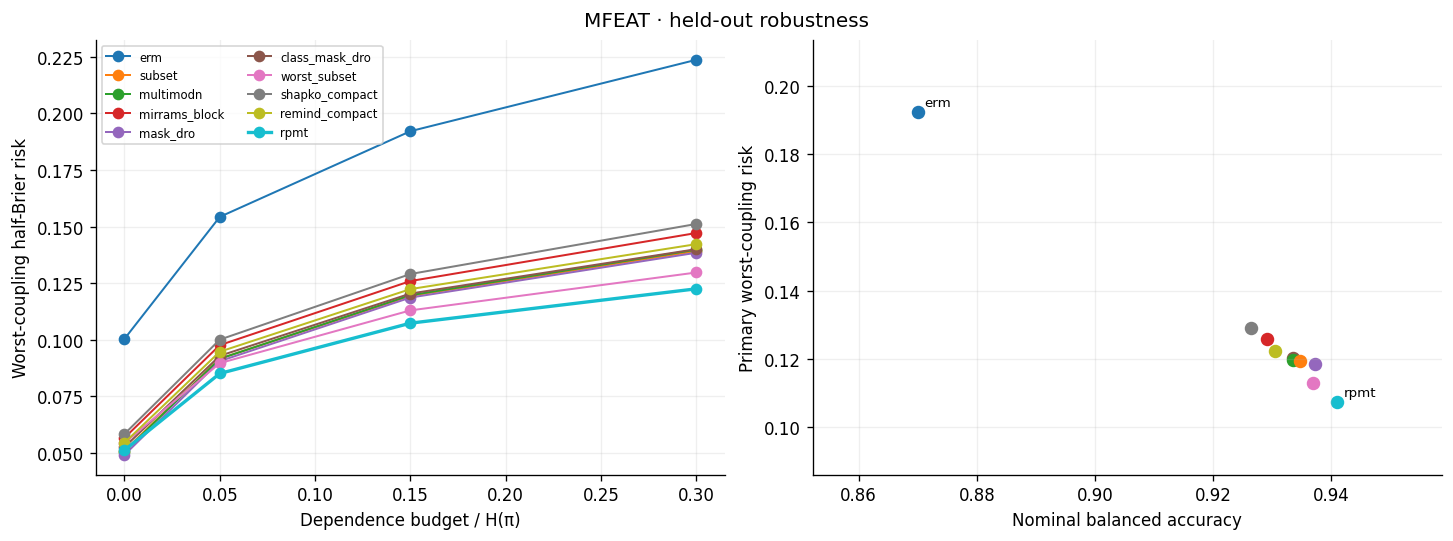

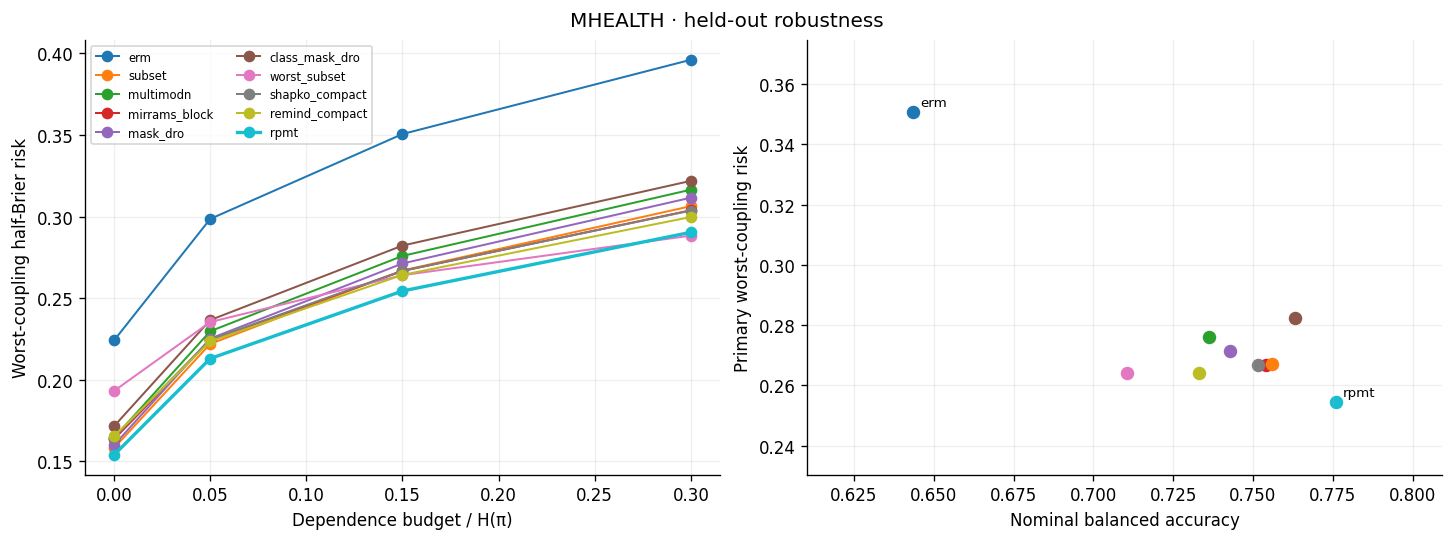

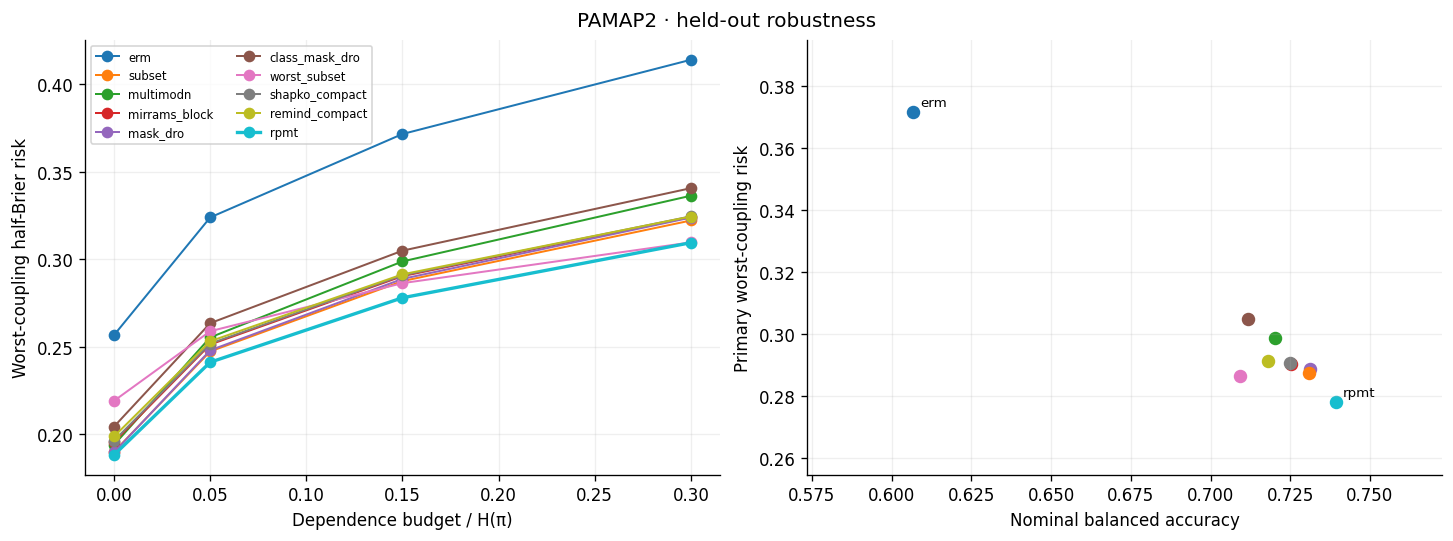

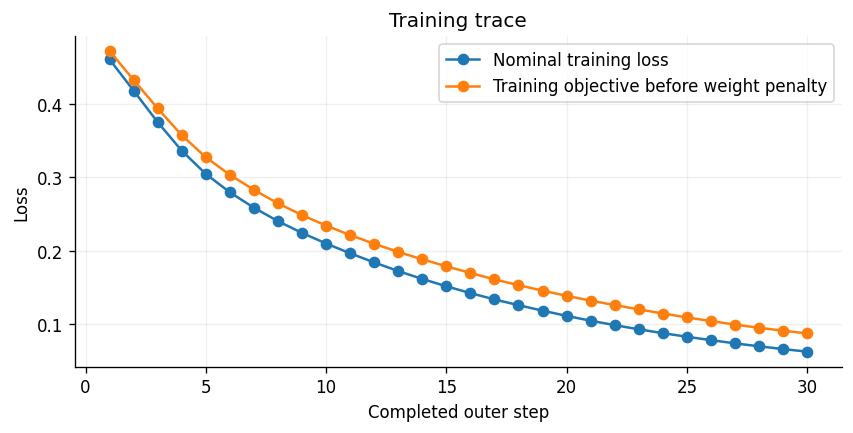

In [ ]:
RESULTS=[]
if CFG.mode=="study" and RUNS:
    atomic_json(ROOT/"exports"/"test_evaluation_started.json",{"protocol_hash":STUDY_STATUS["protocol_hash"],
                "utc":datetime.now(timezone.utc).isoformat()})
for run in RUNS:
    if not run["complete"]: continue
    spec=run["spec"]; test=get_data(spec.dataset,spec.partition,spec.raw,spec.views)[2]
    RESULTS.append(evaluate_fit(run,test))

METRICS,SUBJECT_METRICS,MECHANISMS,COMPARISONS=summarize_results(RESULTS,CHOICES)
INTERVALS=paired_cluster_intervals(SUBJECT_METRICS,COMPARISONS) if len(COMPARISONS) else pd.DataFrame()

def native_gap_sensitivity(runs):
    reports=[]
    if CFG.mode!="study" or not STUDY_STATUS.get("completed_all"): return reports
    # Frozen trained models; assess only test preprocessing. No refitting or test-driven model selection.
    for run in runs:
        s=run["spec"]
        if s.dataset!="pamap2" or s.partition!=0 or s.stage!="main": continue
        key=(s.dataset,s.partition,s.seed)
        if s.method!="rpmt" and run["fingerprint"]!=CHOICES[key][2]: continue
        for gap in (0.,.5):
            native=sensor_data("pamap2",0,"test",False,gap)
            native.x=[((x-np.array(st["mean"]))/np.array(st["std"])).astype(np.float32) for x,st in zip(native.x,run["scaler"])]
            native.check(); p=predict_matrix(run["model"],native); pi=np.full(p.shape[1],1/p.shape[1])
            q,info=solve_risk(brier_matrix(p,native.y),pi,CFG.rho_fraction*entropy(pi))
            reports.append({"seed":s.seed,"method":s.method,"gap_seconds":gap,"included_windows":len(native),
                            "risk":info["risk"],"audit":native.meta["audit"],
                            "interpretation":"Selected complete windows under alternate gap rules; not recovery of naturally absent modalities."})
    return reports

NATIVE_GAP_RESULTS=native_gap_sensitivity(RUNS)
EXPORTS=ROOT/"exports"
for name,table in (("metrics",METRICS),("subject_metrics",SUBJECT_METRICS),("shared_mechanisms",MECHANISMS),
                   ("paired_comparisons",COMPARISONS),("cluster_intervals",INTERVALS)):
    if not table.empty: atomic_bytes(EXPORTS/(name+".csv"),table.to_csv(index=False).encode())
atomic_json(EXPORTS/"native_gap_sensitivity.json",NATIVE_GAP_RESULTS)
atomic_json(EXPORTS/"study_status.json",STUDY_STATUS)
atomic_json(EXPORTS/"results.json",RESULTS)
completion=pd.DataFrame([{**asdict(r["spec"]),"complete":r["complete"],"resumed_completed_run":r["skipped"],
                         "fingerprint":r["fingerprint"],"seconds":r["elapsed_seconds"]} for r in RUNS])
atomic_bytes(EXPORTS/"run_completion.csv",completion.to_csv(index=False).encode())

if not METRICS.empty:
    selected=METRICS[(METRICS.pi=="uniform")&(METRICS.rho_fraction==CFG.rho_fraction)&METRICS.stage.isin(["main","smoke"])]
    print("Synthetic smoke metrics — not research evidence" if CFG.mode=="smoke" else "Held-out primary metrics")
    print(selected.groupby(["dataset","method"])[["brier","balanced_accuracy","macro_f1"]].mean().round(5).to_string())
    if not INTERVALS.empty: print("\nPaired intervals conditional on fixed fitted models:\n",INTERVALS.to_string(index=False))

FIGURES=[]
if not METRICS.empty:
    plt.rcParams.update({"font.size":10,"axes.spines.top":False,"axes.spines.right":False,"figure.dpi":120})
    core=METRICS[(METRICS.pi=="uniform")&METRICS.stage.isin(["main","smoke"])]
    for dataset,data in core.groupby("dataset"):
        fig,axes=plt.subplots(1,2,figsize=(12,4.4),constrained_layout=True)
        colors={method:plt.get_cmap("tab10")(j%10) for j,method in enumerate(METHODS)}
        for method,group in data.groupby("method",sort=False):
            curve=group.groupby("rho_fraction").brier.mean()
            axes[0].plot(curve.index,curve.values,marker="o",linewidth=2 if method=="rpmt" else 1.2,label=method,color=colors[method])
        axes[0].set(xlabel="Dependence budget / H(π)",ylabel="Worst-coupling half-Brier risk")
        axes[0].grid(alpha=.2); axes[0].legend(fontsize=7,ncol=2)
        nom=data[data.rho_fraction==0].groupby("method").balanced_accuracy.mean()
        robust=data[data.rho_fraction==CFG.rho_fraction].groupby("method").brier.mean()
        annotated={"rpmt",nom.idxmax(),robust.idxmax()}
        for method in nom.index.intersection(robust.index):
            axes[1].scatter(nom[method],robust[method],s=50,color=colors[method])
            if method in annotated: axes[1].annotate(method,(nom[method],robust[method]),xytext=(4,4),textcoords="offset points",fontsize=8)
        axes[1].set(xlabel="Nominal balanced accuracy",ylabel="Primary worst-coupling risk")
        axes[1].margins(.25); axes[1].grid(alpha=.2)
        fig.suptitle(f"{dataset.upper()} · "+("synthetic smoke test only" if dataset=="synthetic" else "held-out robustness"))
        path=EXPORTS/(dataset+"_risk_curves.png"); fig.savefig(path,dpi=160); FIGURES.append(path)
        plt.show()
    first=next((r for r in RUNS if r["spec"].method=="rpmt" and r["spec"].stage in ("main","smoke")),None)
    if first:
        fig,ax=plt.subplots(figsize=(7,3.5),constrained_layout=True)
        ax.plot([h["step"] for h in first["history"]],[h["nominal_train_loss"] for h in first["history"]],"o-",label="Nominal training loss")
        ax.plot([h["step"] for h in first["history"]],[h["objective"] for h in first["history"]],"o-",label="Training objective before weight penalty")
        ax.set(xlabel="Completed outer step",ylabel="Loss",title="Training trace"); ax.legend(); ax.grid(alpha=.2)
        path=EXPORTS/"training_trace.png"; fig.savefig(path,dpi=160); FIGURES.append(path); plt.show()

# Prespecified criteria are descriptive point estimates, never automatic publication claims.
CRITERIA={"threshold":"At least 10% lower primary risk, <= 0.01 nominal balanced-accuracy cost, on at least two real datasets",
          "status":"NOT ASSESSED: synthetic smoke mode" if CFG.mode=="smoke" else "INCOMPLETE",
          "official_paper_reproductions":False,"all_293_fits_complete":CFG.mode=="study" and STUDY_STATUS.get("completed_all",False),
          "torch_backend_executed":BACKEND=="torch","real_download_pipeline_executed":CFG.mode in ("pilot","study")}
if CFG.mode=="study" and STUDY_STATUS.get("completed_all") and not COMPARISONS.empty:
    grouped=COMPARISONS.groupby("dataset")[["relative_risk_reduction","nominal_balanced_accuracy_cost"]].mean()
    passed=(grouped.relative_risk_reduction>=.10)&(grouped.nominal_balanced_accuracy_cost<=.01)
    CRITERIA.update(status="POINT-ESTIMATE CRITERION MET" if passed.sum()>=2 else "POINT-ESTIMATE CRITERION NOT MET",
                    dataset_summaries=grouped.reset_index().to_dict("records"),datasets_meeting_threshold=int(passed.sum()),
                    uncertainty_note="Inspect subject intervals, all partitions, shared mechanisms, controls and convergence before making a claim.")
atomic_json(EXPORTS/"criteria.json",CRITERIA)

# A small inference artifact contains weights, scaler, prior, mask support and the architecture.
if RUNS:
    candidate=next((r for r in RUNS if r["spec"].method=="rpmt" and r["complete"]),None)
    if candidate:
        save_bundle(EXPORTS/"rpmt_inference.zip",{"spec":asdict(candidate["spec"]),"scaler":candidate["scaler"],
            "prior":candidate["prior"].tolist(),"input_shapes":candidate["model"].input_shapes,
            "classes":candidate["model"].classes,"class_ids":candidate["class_ids"],"mask_support":candidate["model"].masks.tolist(),
            "architecture":candidate["model"].architecture,"width":candidate["model"].width,
            "data_kind":"synthetic" if candidate["spec"].dataset=="synthetic" else "real",
            "pipeline":PIPELINE_VERSION},candidate["model"].state())
        restored,inference_meta=load_inference_model(EXPORTS/"rpmt_inference.zip")
        spec=candidate["spec"]; test=get_data(spec.dataset,spec.partition,spec.raw,spec.views)[2].subset(np.arange(3))
        np.testing.assert_allclose(predict_matrix(restored,test),predict_matrix(candidate["model"],test),atol=2e-6)
        TEST_REPORT["inference_export_roundtrip"]="PASS"
        atomic_json(EXPORTS/"smoke_checks.json",TEST_REPORT)

manifest={"pipeline":PIPELINE_VERSION,"environment":ENV,"study_status":STUDY_STATUS,"criteria":CRITERIA,
          "files":[{"name":p.name,"bytes":p.stat().st_size,"sha256":digest_file(p)}
                   for p in sorted(EXPORTS.iterdir()) if p.is_file() and p.name not in ("artifact_manifest.json","results_bundle.zip")],
          "tests":TEST_REPORT}
atomic_json(EXPORTS/"artifact_manifest.json",manifest)
archive=io.BytesIO()


In [ ]:
with zipfile.ZipFile(archive,"w",zipfile.ZIP_DEFLATED) as z:
    for p in sorted(EXPORTS.iterdir()):
        if p.is_file() and p.name!="results_bundle.zip": z.write(p,p.name)
atomic_bytes(EXPORTS/"results_bundle.zip",archive.getvalue())
print(json.dumps(CRITERIA,indent=2))
print(f"Exported {len(manifest['files'])} result artifacts. Full resumable states remain in {ROOT/'runs'}.")


{
  "threshold": "At least 10% lower primary risk, <= 0.01 nominal balanced-accuracy cost, on at least two real datasets",
  "status": "POINT-ESTIMATE CRITERION NOT MET",
  "official_paper_reproductions": false,
  "all_293_fits_complete": true,
  "torch_backend_executed": true,
  "real_download_pipeline_executed": true,
  "dataset_summaries": [
    {
      "dataset": "mfeat",
      "relative_risk_reduction": 0.09683515857811281,
      "nominal_balanced_accuracy_cost": -0.007619047619047525
    },
    {
      "dataset": "mhealth",
      "relative_risk_reduction": 0.06720063647367415,
      "nominal_balanced_accuracy_cost": -0.04824425452290421
    },
    {
      "dataset": "pamap2",
      "relative_risk_reduction": 0.045476468974306176,
      "nominal_balanced_accuracy_cost": -0.019674508449994174
    }
  ],
  "datasets_meeting_threshold": 0,
  "uncertainty_note": "Inspect subject intervals, all partitions, shared mechanisms, controls and convergence before making a claim."
}
Exported 2

## 10 Output guide and remaining research gates

| File | Purpose |
|---|---|
| `smoke_checks.json` | Numerical, gradient, parser, checkpoint, and inference tests |
| `protocol_*.json`, `selection_*.json` | Frozen configuration, splits, fit plan, and validation decisions |
| `run_completion.csv` | Completed and partial run accounting |
| `metrics.csv` | Budget curves, metrics, runtime, size, and solver certificates |
| `subject_metrics.csv`, `cluster_intervals.csv` | Conditional subject effects and uncertainty |
| `shared_mechanisms.csv` | Shared stress metrics and exact achieved counts |
| `paired_comparisons.csv` | RPMT versus the validation-selected baseline |
| `native_gap_sensitivity.json` | PAMAP2 test-selection sensitivity after full study |
| `timing_pilot.json` | Measured components and projected runtime |
| `rpmt_inference.zip` | Portable inference model, scaler, class IDs, and prior |
| `artifact_manifest.json` | File hashes, environment, completion status, and test report |
| `results_bundle.zip` | Reports, tables, figures, and inference artifact |

Complete paired training data are required. Native missingness, scarce subjects, exhaustive-mask growth, budget sensitivity, and compact baseline fidelity remain limitations. No assumed 2% gain, global novelty claim, or population guarantee is made. The next gates are a real GPU pilot, convergence inspection, the frozen real study, and validation against the authors' official baselines.

On solver failure, inspect the certificate and loss scale; do not substitute independent masks and keep the RPMT label. Reduce chunk size for memory pressure using a new run identity. Keep source archive hashes and split manifests. Changed hardware/dependencies may require a new training identity even though inference weights are portable. For failed network downloads, supply the official ZIP files locally as described above.

### Sources

The attached proposal defines the research task. Dataset and implementation details were checked against these primary sources. Literature links below are those identified by the proposal; compact implementations are disclosed in section 5.

- [MHEALTH and licensing](https://archive.ics.uci.edu/dataset/319/mhealth+dataset)
- [PAMAP2 protocol and channel layout](https://archive.ics.uci.edu/dataset/231/pamap2+physical+activity+monitoring)
- [Multiple Features aligned views](https://archive.ics.uci.edu/dataset/72/multiple+features)
- [SciPy HiGHS linear programming](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.linprog.html)
- [SciPy polyphase resampling](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.resample_poly.html)
- [PyTorch saving/loading guidance](https://docs.pytorch.org/tutorials/beginner/saving_loading_models.html)
- [ModDrop](https://arxiv.org/abs/1501.00102), [MultiModN](https://arxiv.org/abs/2309.14118), [MIRRAMS](https://arxiv.org/abs/2507.08280)
- [REMIND](https://arxiv.org/abs/2603.00046), [ShapKO](https://papers.miccai.org/miccai-2026/0956-Paper3767.html)

Preserve dataset attribution and applicable licenses. Sensor traces can reveal behavioral information. This is a research implementation, not a clinically or operationally validated monitoring system.
